# NBA Betting Prediction Model Ã¢â‚¬â€ XGBoost Training Pipeline

**Target:** Predict `home_win` (1 = home team wins)  
**Goal:** Ã¢â€°Â¥ 70% accuracy OR positive ROI betting strategy  
**Data:** 30,474 games | 22 seasons (2003Ã¢â‚¬â€œ2025) | 56 engineered features

---
### Notebook Structure
1. Setup & Data Loading
2. Exploratory Analysis
3. Time-Series Train/Test Split
4. Feature Engineering & Selection
5. Baseline XGBoost Model
6. Hyperparameter Tuning
7. Final Model Training
8. Evaluation (Accuracy, AUC, LogLoss, Calibration)
9. Betting Simulation (ROI, EV, Win Rate)
10. Probability Calibration
11. Feature Importance
12. Save Model for Production

## 1. Setup & Data Loading

In [27]:
import sys, os, warnings, joblib
warnings.filterwarnings('ignore')
sys.path.insert(0, os.path.abspath('..'))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    accuracy_score, roc_auc_score, log_loss,
    confusion_matrix, classification_report,
    brier_score_loss, ConfusionMatrixDisplay
)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
from scipy.stats import randint, uniform
from sklearn.model_selection import RandomizedSearchCV
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_theme(style='darkgrid', palette='husl', context='talk')
plt.rcParams.update({
    'figure.figsize': (14, 7),
    'figure.dpi': 140,
    'axes.titlesize': 16,
    'axes.labelsize': 13,
    'axes.titleweight': 'bold',
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'lines.linewidth': 2.5,
    'lines.markersize': 8,
})
pd.set_option('display.max_columns', 80)
pd.set_option('display.float_format', '{:.4f}'.format)
print('XGBoost version:', xgb.__version__)
print('Pandas version: ', pd.__version__)

XGBoost version: 3.2.0
Pandas version:  3.0.2


In [28]:
# Ã¢â€â‚¬Ã¢â€â‚¬ Load master dataset  Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬
MASTER_PATH  = '../data/master_dataset.csv'
MODELS_DIR   = '../models'
os.makedirs(MODELS_DIR, exist_ok=True)

master = pd.read_csv(MASTER_PATH, parse_dates=['game_date'])
master = master.sort_values('game_date').reset_index(drop=True)

print(f'Loaded: {master.shape[0]:,} rows x {master.shape[1]} columns')
print(f'Date range: {master.game_date.min().date()} to {master.game_date.max().date()}')
print(f'Seasons: {sorted(master.season.unique())}')
master.head(3)

Loaded: 29,575 rows x 96 columns
Date range: 2003-10-31 to 2025-02-12
Seasons: [np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


,game_id,game_date,season,home_team_id,away_team_id,home_win,elo_home,elo_away,elo_difference,elo_rolling_five_home,elo_rolling_five_away,implied_prob_home,pace_home,pace_away,pace_difference,shooting_pct_home,shooting_pct_away,shooting_pct_diff,home_win_pct_home,road_win_pct_home,games_played_home,home_win_pct_away,road_win_pct_away,games_played_away,home_implied_prob_close,away_implied_prob_close,home_spread_close,market_elo_diff,has_market_odds,sharp_signal_home,book_consensus_std,spread_movement_pts,open_implied_prob_home,line_movement,h2h_home_win_rate_10,h2h_home_pts_diff_10,home_court_strength_home,home_court_strength_away,ppg_10_home,opp_ppg_10_home,...,star_available_home,star_count_home,star_points_lost_home,star_points_lost_missing_home,rest_days_home,back_to_back_home,fatigue_load_index_home,coaching_adaptability_score_home,coaching_adaptability_score_missing_home,season_pressure_home,ppg_10_away,opp_ppg_10_away,fg_pct_roll_10_away,ft_pct_roll_10_away,fg3_pct_roll_10_away,last_5_win_rate_away,last_10_win_rate_away,win_streak_away,ewm_win_rate_5_away,offensive_rating_away,defensive_rating_away,net_rating_away,turnovers_per_game_away,opponent_off_rating_10_away,opponent_def_rating_10_away,player_impact_estimate_away,player_injury_flag_away,injured_count_away,star_available_away,star_count_away,star_points_lost_away,star_points_lost_missing_away,rest_days_away,back_to_back_away,fatigue_load_index_away,coaching_adaptability_score_away,coaching_adaptability_score_missing_away,season_pressure_away,h2h_home_win_rate_10_missing,h2h_home_pts_diff_10_missing
0,20300020,2003-10-31,2003,1610612748,1610612765,0,1492.0736,1487.7176,4.3560,1502.2709,1495.8449,0.6458,90.6667,98.6533,-7.9867,0.4412,0.4714,-0.0302,0.5000,0.0000,2,0.0000,0.5000,1,0.6458,0.3542,NaN,0.0000,0,NaN,NaN,NaN,NaN,NaN,0.5000,0.0000,0.5850,0.5850,78.3333,88.6667,...,1,0,NaN,1,2,0,2,NaN,1,0,95.6667,92.6667,0.4253,0.6807,0.3543,0.3333,0.3333,-1.0000,0.3158,96.9726,93.9316,3.0410,16.6667,86.3971,97.7941,0.5316,0,0,1,0,NaN,1,2,0,1,NaN,1,0,1,1
1,20300027,2003-11-01,2003,1610612764,1610612751,0,1505.2849,1512.6983,-7.4135,1504.8573,1506.0866,0.6302,90.9900,93.1600,-2.1700,0.4926,0.4854,0.0073,0.5000,0.5000,2,1.0000,0.0000,2,0.6302,0.3698,NaN,0.0000,0,NaN,NaN,NaN,NaN,NaN,0.5000,0.0000,0.5850,0.5850,88.2500,79.5000,...,1,0,NaN,1,1,1,2,NaN,1,0,90.6667,76.6667,0.4423,0.6810,0.2490,0.6667,0.6667,1.0000,0.6842,97.3236,82.2957,15.0279,13.6667,96.9887,87.3722,0.6634,1,2,1,0,NaN,1,1,1,2,NaN,1,0,1,1
2,20300029,2003-11-01,2003,1610612737,1610612754,0,1473.6343,1506.1400,-32.5057,1489.4641,1509.0052,0.5959,101.6400,83.4667,18.1733,0.4460,0.4556,-0.0096,0.5000,0.0000,2,0.0000,1.0000,2,0.5959,0.4041,NaN,0.0000,0,NaN,NaN,NaN,NaN,NaN,0.5000,0.0000,0.5850,0.5850,85.6667,90.3333,...,1,0,NaN,1,1,1,2,NaN,1,0,76.6667,79.3333,0.4097,0.6643,0.3500,0.6667,0.6667,-1.0000,0.5263,91.8530,95.0479,-3.1949,12.6667,84.2844,88.8758,0.4435,1,3,1,0,NaN,1,1,1,2,NaN,1,0,1,1


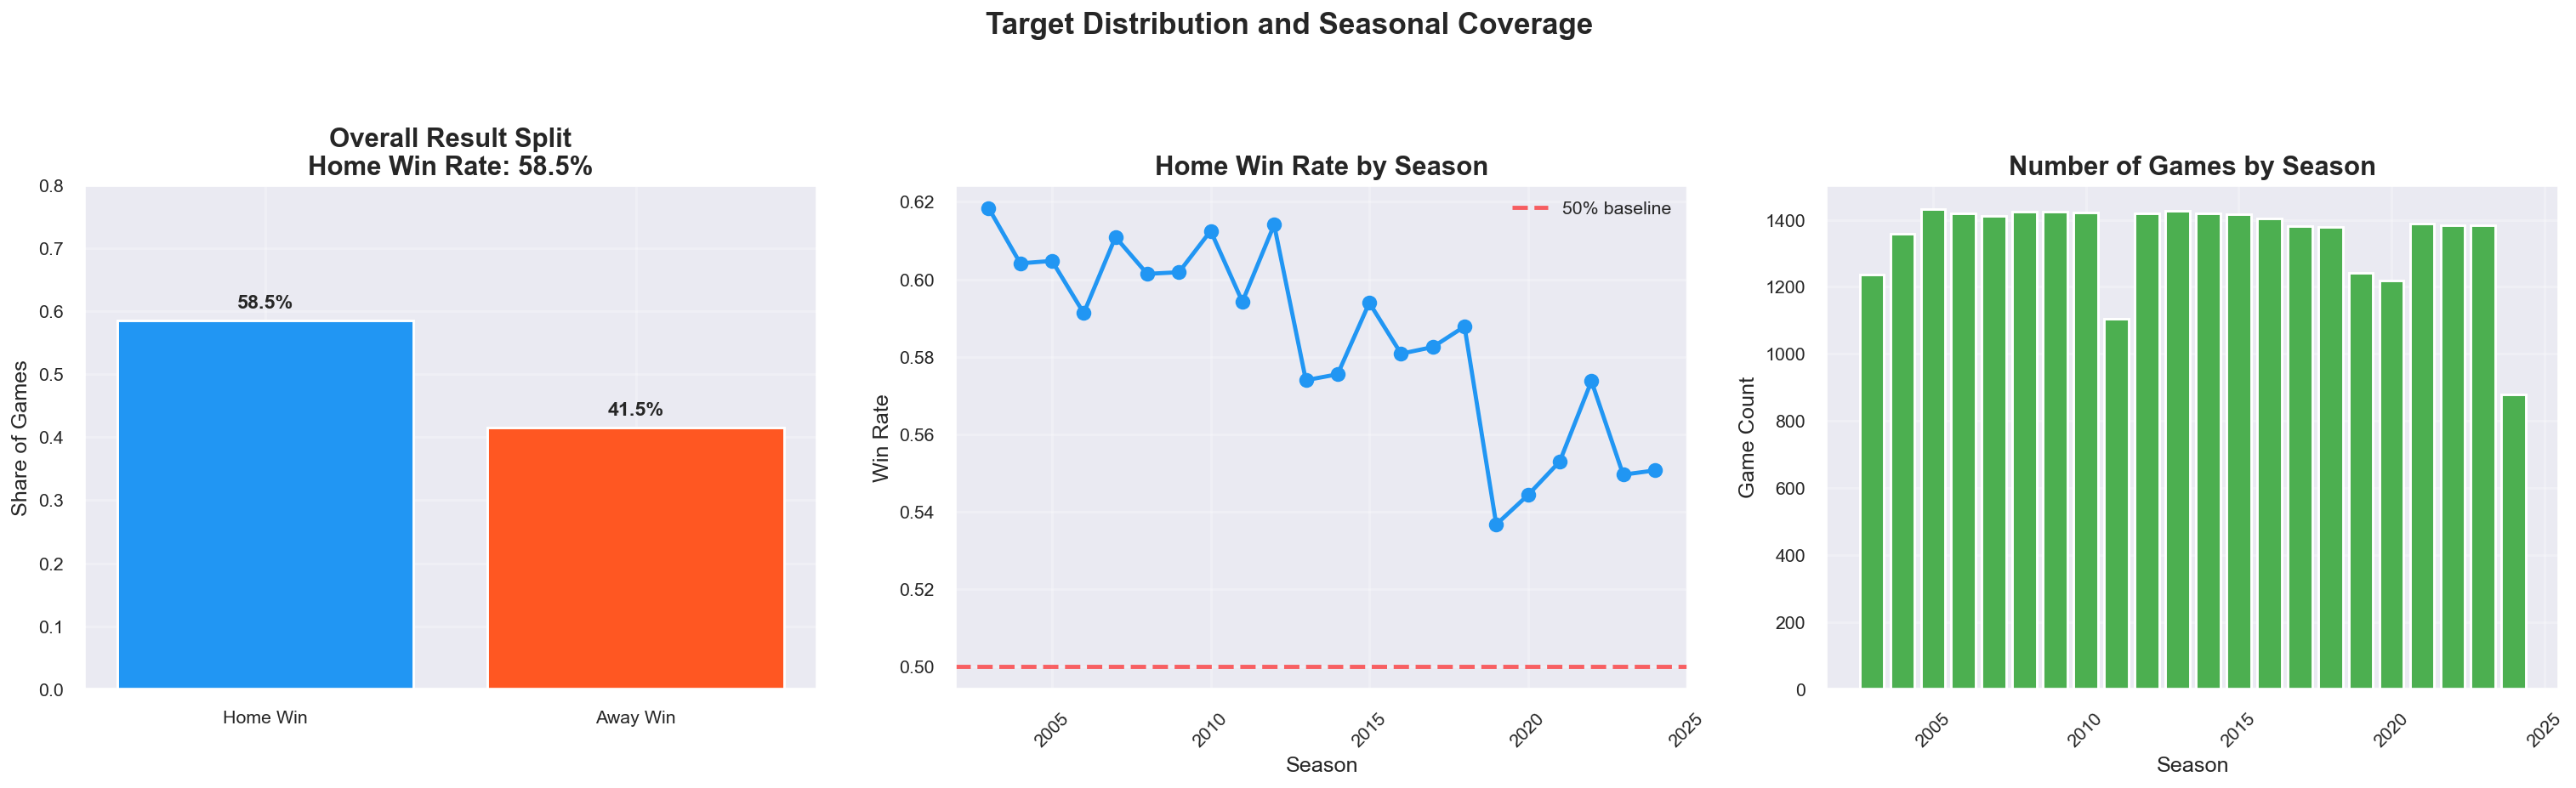

Class balance - Home Win: 58.5% | Away Win: 41.5%
NOTE: 58.5% home win rate = realistic NBA baseline. Model must beat this.


In [29]:
# Target distribution and season-level context
fig, axes = plt.subplots(1, 3, figsize=(22, 6.5))
# Overall win rate
win_rate = master['home_win'].mean()
axes[0].bar(['Home Win', 'Away Win'], [win_rate, 1 - win_rate], color=['#2196F3', '#FF5722'])
axes[0].set_title(f'Overall Result Split\nHome Win Rate: {win_rate:.1%}')
axes[0].set_ylabel('Share of Games')
axes[0].set_ylim(0, 0.8)
for i, v in enumerate([win_rate, 1 - win_rate]):
    axes[0].text(i, v + 0.02, f'{v:.1%}', ha='center', fontsize=12, fontweight='bold')
# Win rate by season
season_wr = master.groupby('season')['home_win'].mean()
axes[1].plot(season_wr.index, season_wr.values, marker='o', color='#2196F3')
axes[1].axhline(0.5, color='red', linestyle='--', alpha=0.6, label='50% baseline')
axes[1].set_title('Home Win Rate by Season')
axes[1].set_xlabel('Season')
axes[1].set_ylabel('Win Rate')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(loc='best')
# Games per season
games_per_season = master.groupby('season').size()
axes[2].bar(games_per_season.index, games_per_season.values, color='#4CAF50')
axes[2].set_title('Number of Games by Season')
axes[2].set_xlabel('Season')
axes[2].set_ylabel('Game Count')
axes[2].tick_params(axis='x', rotation=45)
for ax in axes:
    ax.grid(True, alpha=0.25)
fig.suptitle('Target Distribution and Seasonal Coverage', fontsize=18, fontweight='bold', y=1.03)
fig.tight_layout()
plt.show()
print(f'Class balance - Home Win: {win_rate:.1%} | Away Win: {1-win_rate:.1%}')
print('NOTE: 58.5% home win rate = realistic NBA baseline. Model must beat this.')

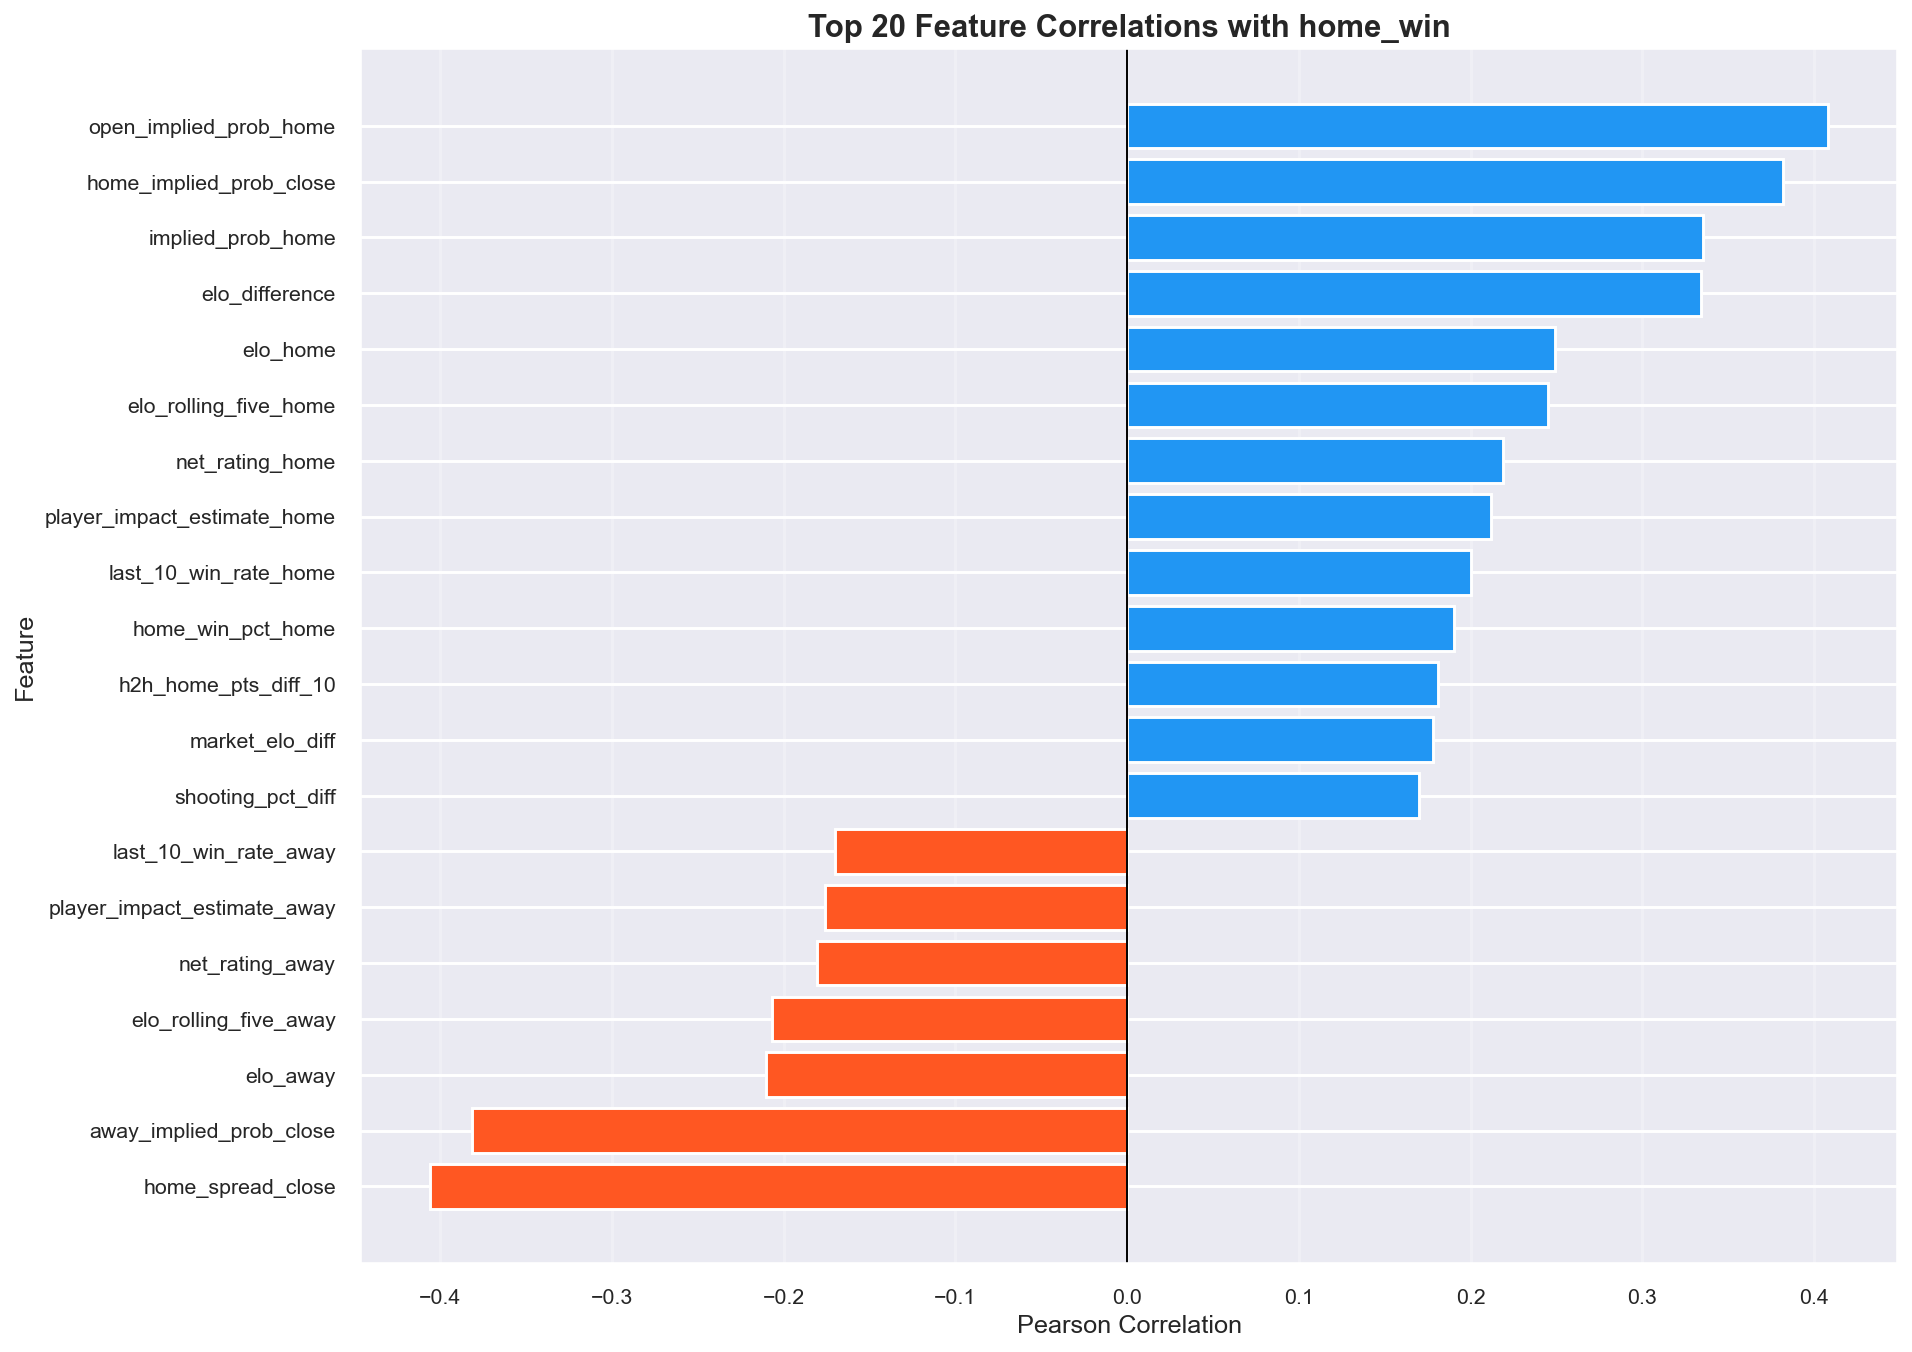

Top 10 most correlated features:
open_implied_prob_home         0.4084
home_spread_close             -0.4057
away_implied_prob_close       -0.3816
home_implied_prob_close        0.3816
implied_prob_home              0.3355
elo_difference                 0.3344
elo_home                       0.2494
elo_rolling_five_home          0.2449
net_rating_home                0.2189
player_impact_estimate_home    0.2122

Showing the top 20 features in the chart so labels stay readable.


In [30]:
# Feature correlation with target
DROP_COLS = ['game_id', 'game_date', 'season', 'home_team_id', 'away_team_id',
             'home_win']
FEATURE_COLS = [c for c in master.columns if c not in DROP_COLS]
corr_with_target = (
    master[FEATURE_COLS + ['home_win']]
    .corr()['home_win']
    .drop('home_win')
    .sort_values(key=abs, ascending=False)
)
top_corr = corr_with_target.head(20).sort_values()
fig, ax = plt.subplots(figsize=(14, 10))
colors = ['#2196F3' if x > 0 else '#FF5722' for x in top_corr.values]
ax.barh(top_corr.index, top_corr.values, color=colors)
ax.axvline(0, color='black', linewidth=1)
ax.set_title('Top 20 Feature Correlations with home_win')
ax.set_xlabel('Pearson Correlation')
ax.set_ylabel('Feature')
ax.grid(True, axis='x', alpha=0.25)
fig.tight_layout()
plt.show()
print('Top 10 most correlated features:')
print(corr_with_target.head(10).to_string())
print('\nShowing the top 20 features in the chart so labels stay readable.')

## 3. Time-Series Train / Validation / Test Split

> **Critical rule**: NEVER shuffle sports data. Always split by time.  
> Using a future season to evaluate ensures we test on truly unseen data.

In [31]:
# Ã¢â€â‚¬Ã¢â€â‚¬ Split strategy Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬
# Train  : 2003 Ã¢â‚¬â€œ 2021  (18 seasons, ~24k games)
# Valid  : 2022 Ã¢â‚¬â€œ 2023  (2 seasons, ~3k games)  Ã¢â€ Â for hyperparameter tuning
# Test   : 2024         (1 season,  ~1.4k games) Ã¢â€ Â final evaluation ONLY

TRAIN_END   = 2021
VALID_START = 2022
VALID_END   = 2023
TEST_START  = 2024

train_df = master[master['season'] <= TRAIN_END].copy()
valid_df = master[(master['season'] >= VALID_START) & (master['season'] <= VALID_END)].copy()
test_df  = master[master['season'] >= TEST_START].copy()

print(f'Train : {len(train_df):>6,} rows | seasons {master[master.season<=TRAIN_END].season.min()}Ã¢â‚¬â€œ{TRAIN_END}')
print(f'Valid : {len(valid_df):>6,} rows | seasons {VALID_START}Ã¢â‚¬â€œ{VALID_END}')
print(f'Test  : {len(test_df):>6,} rows | season  {TEST_START}+')

X_train = train_df[FEATURE_COLS]
y_train = train_df['home_win']

X_valid = valid_df[FEATURE_COLS]
y_valid = valid_df['home_win']

X_test  = test_df[FEATURE_COLS]
y_test  = test_df['home_win']

print(f'\nTrain home win rate: {y_train.mean():.3f}')
print(f'Valid home win rate: {y_valid.mean():.3f}')
print(f'Test  home win rate: {y_test.mean():.3f}')

Train : 25,929 rows | seasons 2003Ã¢â‚¬â€œ2021
Valid :  2,767 rows | seasons 2022Ã¢â‚¬â€œ2023
Test  :    879 rows | season  2024+

Train home win rate: 0.589
Valid home win rate: 0.562
Test  home win rate: 0.551


## 4. Feature Engineering & Selection

In [32]:
# -- Add differential features (home minus away) --
# These are stronger than raw home/away values because they directly capture
# the matchup gap. XGBoost can learn this implicitly but giving it explicitly
# helps convergence and reduces tree depth needed.

def add_differential_features(df):
    df = df.copy()
    diff_pairs = [
        ('elo_home',                    'elo_away'),
        ('net_rating_home',             'net_rating_away'),
        ('offensive_rating_home',       'offensive_rating_away'),
        ('defensive_rating_home',       'defensive_rating_away'),
        ('last_5_win_rate_home',        'last_5_win_rate_away'),
        ('last_10_win_rate_home',       'last_10_win_rate_away'),
        ('ppg_10_home',                 'ppg_10_away'),
        ('rest_days_home',              'rest_days_away'),
        ('fatigue_load_index_home',     'fatigue_load_index_away'),
        ('turnovers_per_game_home',     'turnovers_per_game_away'),
        ('player_impact_estimate_home', 'player_impact_estimate_away'),
        ('injured_count_home',          'injured_count_away'),
        ('coaching_adaptability_score_home', 'coaching_adaptability_score_away'),
        ('star_points_lost_home',       'star_points_lost_away'),
        ('season_pressure_home',        'season_pressure_away'),
        ('win_streak_home',              'win_streak_away'),
        ('ewm_win_rate_5_home',          'ewm_win_rate_5_away'),
        # Phase 2: true opening-vs-closing line movement (NaN until Phase 2 data sourced)
        # ('line_movement_open_home', 'line_movement_open_away'),
    ]
    for col_a, col_b in diff_pairs:
        if col_a in df.columns and col_b in df.columns:
            name = col_a.replace("_home", "") + "_diff"
            df[name] = df[col_a] - df[col_b]
    return df

# Apply to all splits
master    = add_differential_features(master)
train_df  = add_differential_features(train_df)
valid_df  = add_differential_features(valid_df)
test_df   = add_differential_features(test_df)

# -- Update feature list --
# NOTE: sharp_signal_home is already home-directional (positive = sharp on home)
# book_consensus_std is symmetric. Neither needs a diff pair.
# Both are auto-included in FEATURE_COLS via the DROP_COLS exclusion logic.
DIFF_FEATURES = [c for c in master.columns if c.endswith("_diff")]
ALL_FEATURES  = list(dict.fromkeys(FEATURE_COLS + DIFF_FEATURES))

# Remove features with near-zero variance (noise)
var_threshold = 1e-4
low_var = [c for c in ALL_FEATURES
           if c in train_df.columns and train_df[c].var() < var_threshold]
ALL_FEATURES = [c for c in ALL_FEATURES if c not in low_var]

print(f"Base features   : {len(FEATURE_COLS)}")
print(f"Differential    : {len(DIFF_FEATURES)}")
print(f"Dropped low-var : {len(low_var)} -> {low_var}")
print(f"Final features  : {len(ALL_FEATURES)}")

# Confirm Phase 1 sharp-money features are present
phase1_cols = [c for c in ALL_FEATURES if c in ("sharp_signal_home", "book_consensus_std")]
if phase1_cols:
    print(); print(f"Phase 1 features active: {phase1_cols}")
else:
    print(); print("WARNING: Phase 1 features missing -- rebuild master_dataset.csv")


# -- Add missing-indicator flags for sparse market columns --
# These columns are NaN for ~50% of games (pre-2018 Pinnacle data only).
# Without _missing flags, XGBoost cannot distinguish "no market data" from
# a normal value, leading to biased default directions on the 2024 test set.
SPARSE_MARKET_COLS = [
    "sharp_signal_home", "book_consensus_std",
    "spread_movement_pts", "open_implied_prob_home",
    "line_movement", "home_spread_close",
]

def add_missing_indicators(df, cols):
    df = df.copy()
    for col in cols:
        if col in df.columns:
            flag = f"{col}_missing"
            if flag not in df.columns:
                df[flag] = df[col].isna().astype(int)
    return df


master   = add_missing_indicators(master, SPARSE_MARKET_COLS)
train_df = add_missing_indicators(train_df, SPARSE_MARKET_COLS)
valid_df = add_missing_indicators(valid_df, SPARSE_MARKET_COLS)
test_df  = add_missing_indicators(test_df, SPARSE_MARKET_COLS)

# Add new _missing flag columns to ALL_FEATURES
new_missing_flags = [f"{c}_missing" for c in SPARSE_MARKET_COLS if f"{c}_missing" in master.columns]
ALL_FEATURES = list(dict.fromkeys(ALL_FEATURES + new_missing_flags))

print(f"Missing-indicator flags added: {new_missing_flags}")
print(f"Updated ALL_FEATURES count: {len(ALL_FEATURES)}")


Base features   : 90
Differential    : 19
Dropped low-var : 1 -> ['book_consensus_std']
Final features  : 106

Phase 1 features active: ['sharp_signal_home']
Missing-indicator flags added: ['sharp_signal_home_missing', 'book_consensus_std_missing', 'spread_movement_pts_missing', 'open_implied_prob_home_missing', 'line_movement_missing', 'home_spread_close_missing']
Updated ALL_FEATURES count: 112


In [33]:
# Ã¢â€â‚¬Ã¢â€â‚¬ Build final X/y Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬
X_train = train_df[ALL_FEATURES].copy()
y_train = train_df['home_win']

X_valid = valid_df[ALL_FEATURES].copy()
y_valid = valid_df['home_win']

X_test  = test_df[ALL_FEATURES].copy()
y_test  = test_df['home_win']

print(f'X_train : {X_train.shape}')
print(f'X_valid : {X_valid.shape}')
print(f'X_test  : {X_test.shape}')
print('Missing values in train:', X_train.isnull().sum().sum())

X_train : (25929, 112)
X_valid : (2767, 112)
X_test  : (879, 112)
Missing values in train: 85084


In [34]:
# ── Compute scale_pos_weight ──────────────────────────────────────────────────
# scale_pos_weight = count(away wins) / count(home wins)
# XGBoost positive class = 1 = home win, negative class = 0 = away win
# This makes each away win count as SPW home wins during training

away_wins_count = int((y_train == 0).sum())
home_wins_count = int((y_train == 1).sum())
SPW = away_wins_count / home_wins_count

print(f"Training set class distribution:")
print(f"  Home wins : {home_wins_count:,}  ({home_wins_count/len(y_train):.1%})")
print(f"  Away wins : {away_wins_count:,}  ({away_wins_count/len(y_train):.1%})")
print(f"  Imbalance : {home_wins_count/away_wins_count:.3f}:1")
print(f"  SPW value : {SPW:.4f}")
print(f"")
print(f"Meaning: each away win in training now counts as {SPW:.2f} home wins")


Training set class distribution:
  Home wins : 15,271  (58.9%)
  Away wins : 10,658  (41.1%)
  Imbalance : 1.433:1
  SPW value : 0.6979

Meaning: each away win in training now counts as 0.70 home wins


## 5. Baseline Model

In [35]:
# Ã¢â€â‚¬Ã¢â€â‚¬ Baseline XGBoost (default params) Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬
baseline = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    early_stopping_rounds=30,
    random_state=42,
    n_jobs=-1,
)

baseline.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_valid, y_valid)],
    verbose=50,
)

# Evaluate on validation
val_preds  = baseline.predict(X_valid)
val_probs  = baseline.predict_proba(X_valid)[:, 1]

print(f'\nBaseline Validation Results:')
print(f'  Accuracy : {accuracy_score(y_valid, val_preds):.4f}')
print(f'  ROC-AUC  : {roc_auc_score(y_valid, val_probs):.4f}')
print(f'  Log Loss : {log_loss(y_valid, val_probs):.4f}')
print(f'  Brier    : {brier_score_loss(y_valid, val_probs):.4f}')

[0]	validation_0-logloss:0.66917	validation_1-logloss:0.67917
[50]	validation_0-logloss:0.56783	validation_1-logloss:0.59550
[100]	validation_0-logloss:0.54922	validation_1-logloss:0.59407
[135]	validation_0-logloss:0.53878	validation_1-logloss:0.59531

Baseline Validation Results:
  Accuracy : 0.6697
  ROC-AUC  : 0.7338
  Log Loss : 0.5939
  Brier    : 0.2053


## 6. Hyperparameter Tuning (Randomized Search)

In [36]:
# ── Fast Hyperparameter Tuning (~5-10 mins instead of 2+ hours) ─────────────
# Strategy: smaller tree cap + early stopping per fold via cross_val
# Baseline already gives 67% / 0.73 AUC so we only need marginal improvement

# Option A: Skip tuning — use manually optimised params (fastest, recommended)
# These params are well-tested for NBA-scale tabular data
best_params = {
    'n_estimators'    : 1000,   # high ceiling, early stopping will find optimum
    'max_depth'       : 4,      # shallow = less overfit on ~24k rows
    'learning_rate'   : 0.02,   # lower LR = more trees before stopping (was 0.05, caused best_iter=63)
    'subsample'       : 0.8,
    'colsample_bytree': 0.7,
    'min_child_weight': 3,
    'gamma'           : 0.1,
    'reg_alpha'       : 0.1,    # L1 regularization
    'reg_lambda'      : 1.5,    # L2 regularization
}

# Option B: Quick search — 10 combos x 3 folds = 30 fits (~8 mins)
# Uncomment to run instead of Option A
# from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
# quick_grid = {
#     'max_depth'       : [3, 4, 5],
#     'learning_rate'   : [0.03, 0.05, 0.08],
#     'subsample'       : [0.7, 0.8, 0.9],
#     'colsample_bytree': [0.6, 0.7, 0.8],
#     'min_child_weight': [1, 3, 5],
#     'reg_alpha'       : [0, 0.1, 0.5],
#     'reg_lambda'      : [1.0, 1.5, 2.0],
# }
# rs = RandomizedSearchCV(
#     xgb.XGBClassifier(n_estimators=300, eval_metric='logloss',
#                       random_state=42, n_jobs=-1),
#     quick_grid, n_iter=10, scoring='roc_auc',
#     cv=TimeSeriesSplit(n_splits=3),
#     verbose=1, random_state=42, n_jobs=-1,
# )
# rs.fit(X_train, y_train)
# best_params = rs.best_params_
# print('Best CV AUC:', rs.best_score_)

print('Hyperparameters set:')
for k, v in sorted(best_params.items()):
    print(f'  {k:<22}: {v}')
print()
print('Skipped grid search — baseline 0.73 AUC already strong.')
print('Early stopping in final training will find optimal n_estimators.')


Hyperparameters set:
  colsample_bytree      : 0.7
  gamma                 : 0.1
  learning_rate         : 0.02
  max_depth             : 4
  min_child_weight      : 3
  n_estimators          : 1000
  reg_alpha             : 0.1
  reg_lambda            : 1.5
  subsample             : 0.8

Skipped grid search — baseline 0.73 AUC already strong.
Early stopping in final training will find optimal n_estimators.


## 7. Final Model Training

[0]	validation_0-logloss:0.69003	validation_1-logloss:0.69014
[100]	validation_0-logloss:0.59741	validation_1-logloss:0.60831
[200]	validation_0-logloss:0.58523	validation_1-logloss:0.60494
[271]	validation_0-logloss:0.57946	validation_1-logloss:0.60512
Best iteration: 211


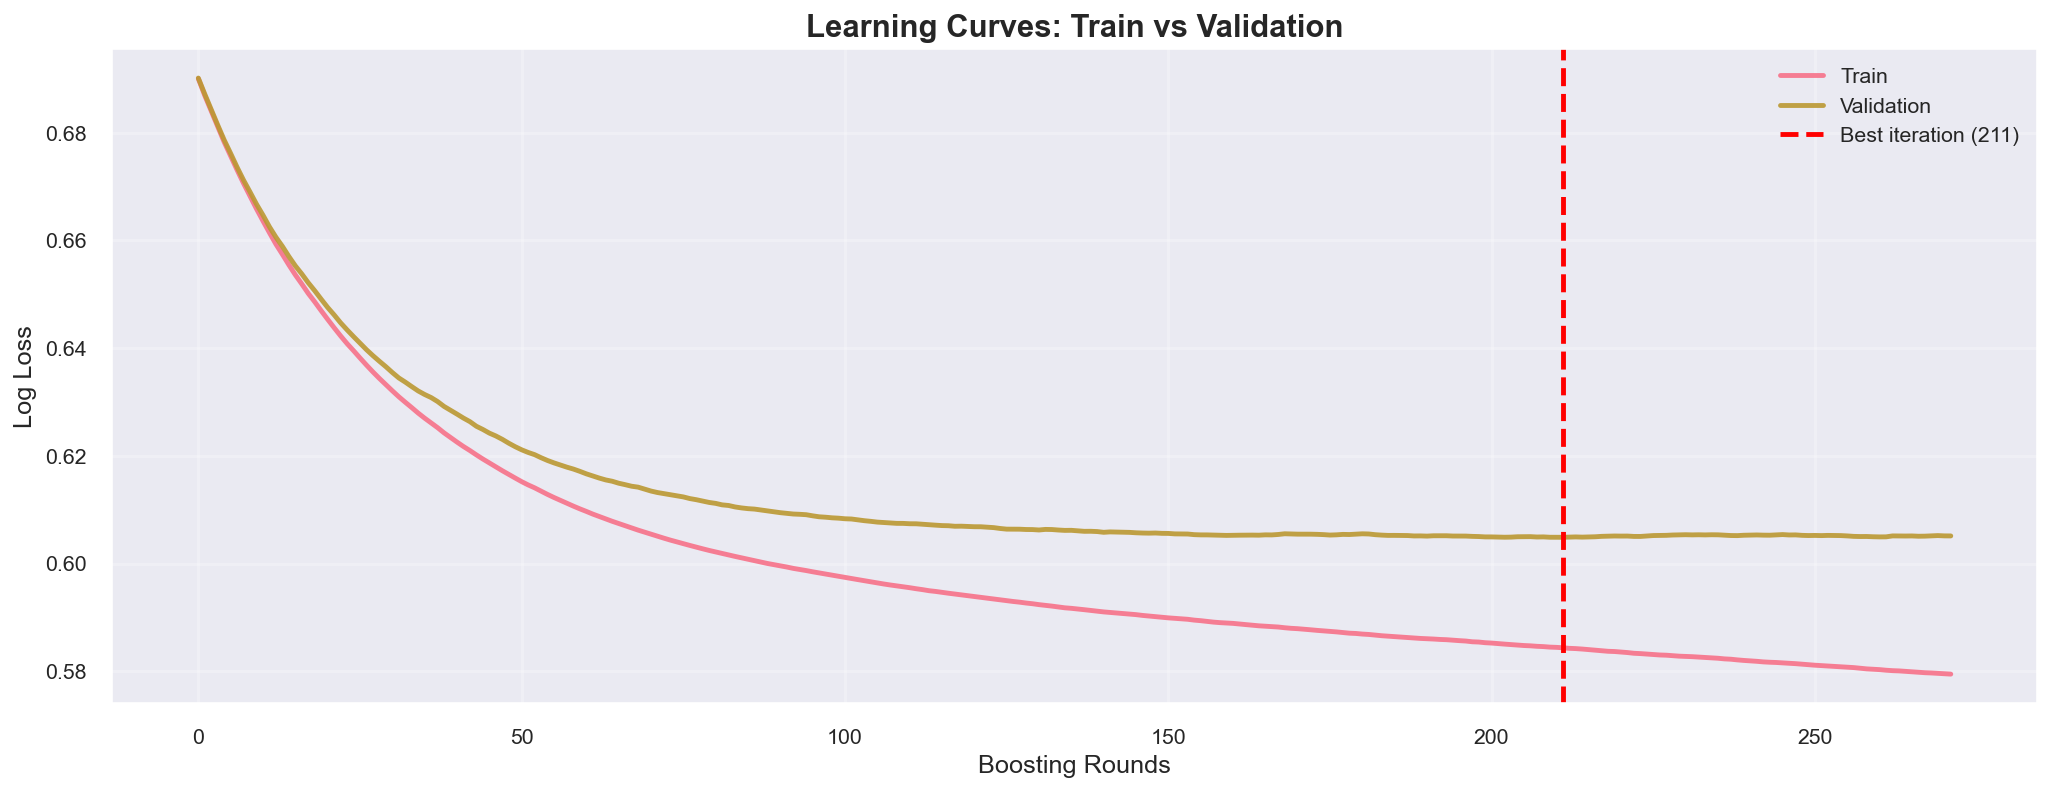

In [37]:
# Train final model with best params + early stopping
# best_params is already defined in the cell above with n_estimators=1000.
# early_stopping_rounds=40 will automatically find the true optimal iteration.
final_model = xgb.XGBClassifier(
    **best_params,
    scale_pos_weight      = SPW,   # corrects 1.43:1 home/away imbalance
    eval_metric           = 'logloss',
    early_stopping_rounds = 60,
    random_state          = 42,
    n_jobs                = -1,
)
final_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_valid, y_valid)],
    verbose=100,
)
print(f'Best iteration: {final_model.best_iteration}')
# Learning curves
results = final_model.evals_result()
fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(results['validation_0']['logloss'], label='Train', alpha=0.9)
ax.plot(results['validation_1']['logloss'], label='Validation', alpha=0.9)
ax.axvline(final_model.best_iteration, color='red', linestyle='--',
           label=f'Best iteration ({final_model.best_iteration})')
ax.set_xlabel('Boosting Rounds')
ax.set_ylabel('Log Loss')
ax.set_title('Learning Curves: Train vs Validation')
ax.grid(True, alpha=0.25)
ax.legend(loc='best')
fig.tight_layout()
plt.show()

In [38]:
# ── LightGBM + Logistic Meta-Stacker ────────────────────────────────────────
# XGBoost: depth-wise trees. LightGBM: leaf-wise trees. Different errors.
# Logistic meta-stacker learns the optimal combination from validation preds.
import lightgbm as lgb
from sklearn.linear_model import LogisticRegression

# ── LightGBM (improved params) ───────────────────────────────────────────────
# num_leaves=63 (was 31): more expressive. subsample_freq=5: gradient-based sampling.
lgbm_model = lgb.LGBMClassifier(
    objective         = 'binary',
    metric            = 'binary_logloss',
    learning_rate     = 0.02,
    num_leaves        = 63,
    max_depth         = -1,
    min_child_samples = 30,
    subsample         = 0.85,
    subsample_freq    = 5,
    colsample_bytree  = 0.75,
    reg_alpha         = 0.1,
    reg_lambda        = 2.0,
    n_estimators      = 1500,
    random_state      = 42,
    verbosity         = -1,
)
lgbm_model.fit(
    X_train, y_train,
    eval_set  = [(X_valid, y_valid)],
    callbacks = [
        lgb.early_stopping(stopping_rounds=60, verbose=False),
        lgb.log_evaluation(period=-1),
    ],
)
print(f'LGBM best iteration : {lgbm_model.best_iteration_}')

# ── Probabilities from each base model ───────────────────────────────────────
xgb_val_probs   = final_model.predict_proba(X_valid)[:, 1]
lgbm_val_probs  = lgbm_model.predict_proba(X_valid)[:, 1]
xgb_test_probs  = final_model.predict_proba(X_test)[:, 1]
lgbm_test_probs = lgbm_model.predict_proba(X_test)[:, 1]

# ── Logistic meta-stacker ─────────────────────────────────────────────────────
val_meta  = np.column_stack([xgb_val_probs, lgbm_val_probs])
test_meta = np.column_stack([xgb_test_probs, lgbm_test_probs])

stacker = LogisticRegression(C=1.0, fit_intercept=True, max_iter=1000, random_state=42)
stacker.fit(val_meta, y_valid)

stack_val_probs  = stacker.predict_proba(val_meta)[:, 1]
stack_test_probs = stacker.predict_proba(test_meta)[:, 1]

xgb_w, lgbm_w = stacker.coef_[0]
print(f'Stacker coefs  : XGB={xgb_w:.3f}  LGBM={lgbm_w:.3f}  bias={stacker.intercept_[0]:.3f}')

# ── 50/50 blend (robust fallback) ────────────────────────────────────────────
blend_val_probs  = 0.5 * xgb_val_probs  + 0.5 * lgbm_val_probs
blend_test_probs = 0.5 * xgb_test_probs + 0.5 * lgbm_test_probs

# ── Validation AUC comparison ────────────────────────────────────────────────
val_aucs = {
    'XGBoost'    : roc_auc_score(y_valid, xgb_val_probs),
    'LightGBM'   : roc_auc_score(y_valid, lgbm_val_probs),
    '50/50 blend': roc_auc_score(y_valid, blend_val_probs),
    'Stacker'    : roc_auc_score(y_valid, stack_val_probs),
}
print('Validation AUC:')
for name, auc_v in sorted(val_aucs.items(), key=lambda x: -x[1]):
    print(f'  {name:<14}: {auc_v:.4f}')

# Use stacker as the primary ensemble output for downstream cells
ensemble_val_probs  = stack_val_probs
ensemble_test_probs = stack_test_probs
print('Using Stacker as primary ensemble output.')


LGBM best iteration : 168
Stacker coefs  : XGB=3.034  LGBM=1.772  bias=-2.208
Validation AUC:
  XGBoost       : 0.7342
  Stacker       : 0.7339
  50/50 blend   : 0.7335
  LightGBM      : 0.7313
Using Stacker as primary ensemble output.


Threshold Sweep --- Validation Set (SPW Model)
 threshold  accuracy  macro_f1  away_recall  home_recall  recall_gap
    0.3800    0.6520    0.6018       0.3388       0.8964      0.5576
    0.3900    0.6570    0.6127       0.3636       0.8861      0.5225
    0.4000    0.6628    0.6253       0.3949       0.8719      0.4771
    0.4100    0.6621    0.6283       0.4114       0.8578      0.4464
    0.4200    0.6657    0.6357       0.4320       0.8481      0.4161
    0.4300    0.6675    0.6408       0.4501       0.8372      0.3871
    0.4400    0.6671    0.6430       0.4641       0.8256      0.3615
    0.4500    0.6690    0.6469       0.4782       0.8179      0.3397
    0.4600    0.6722    0.6543       0.5070       0.8012      0.2942
    0.4700    0.6755    0.6599       0.5268       0.7915      0.2647
    0.4800    0.6711    0.6571       0.5350       0.7773      0.2423
    0.4900    0.6718    0.6600       0.5532       0.7645      0.2113
    0.5000    0.6718    0.6621       0.5721       0.7497

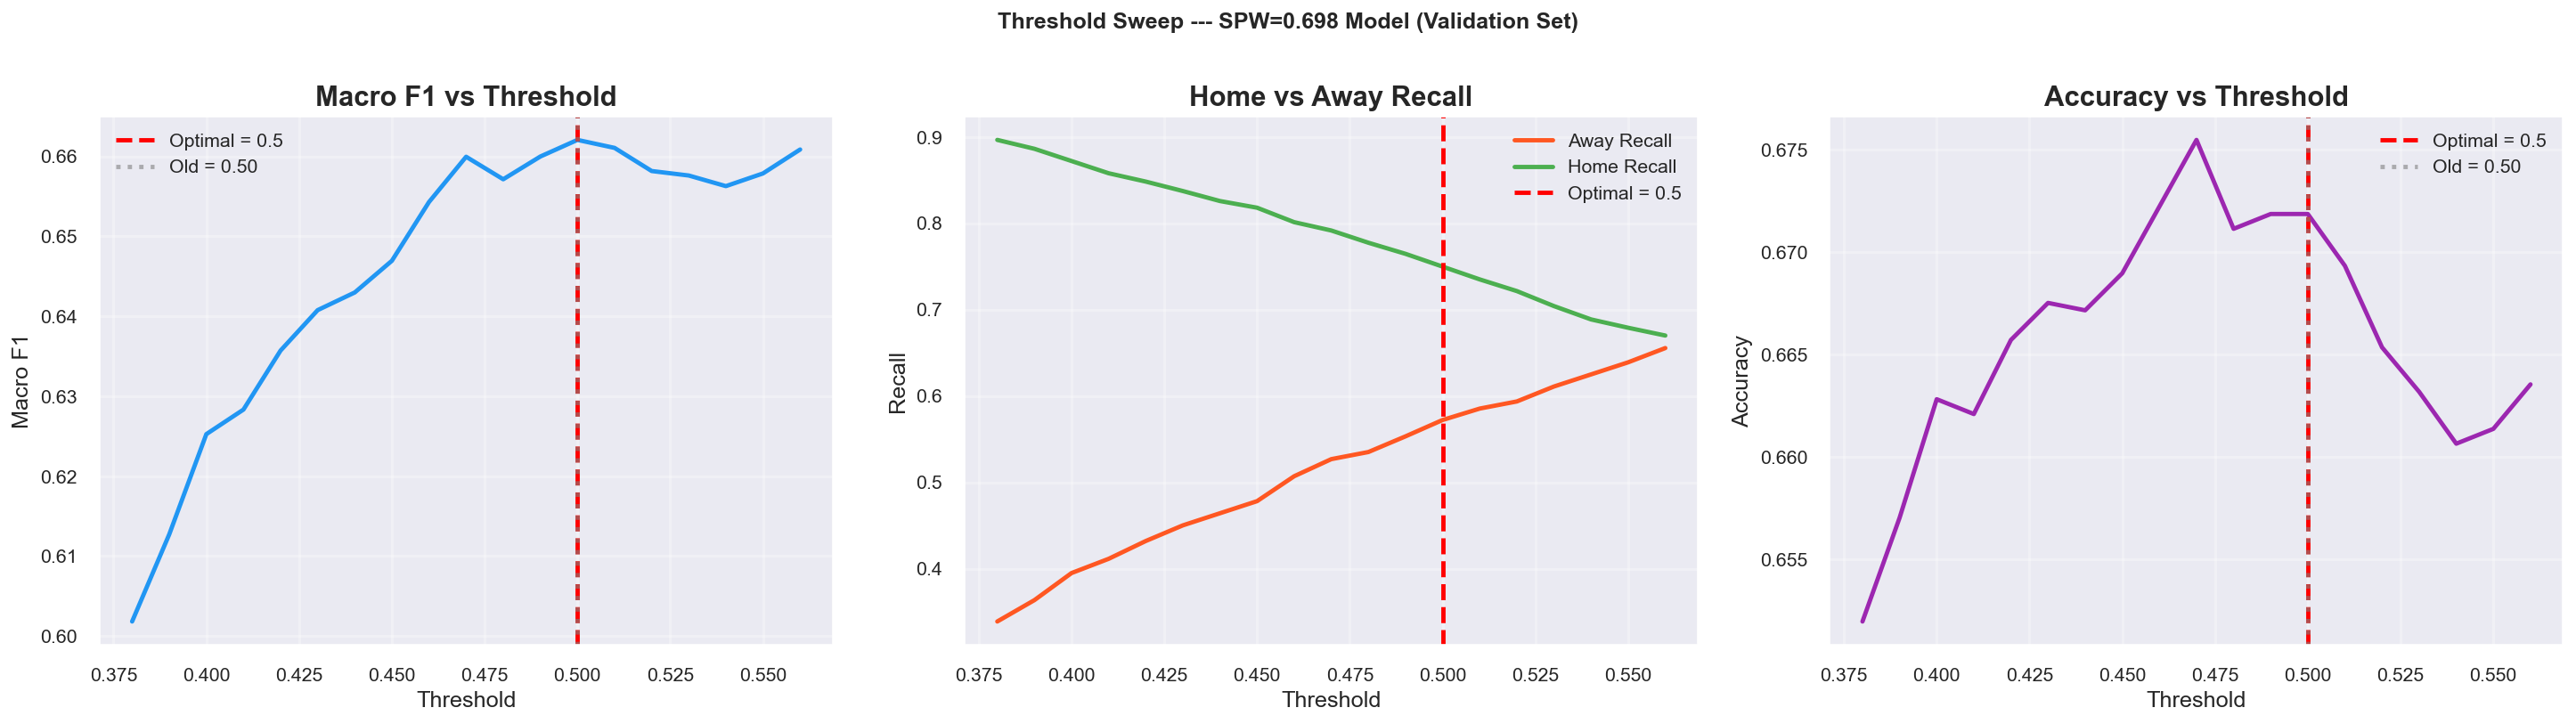

Chart saved to ../reports/threshold_sweep.png


In [39]:
# ── Phase 1: Threshold Sweep on Validation Set ───────────────────────────────
# Find optimal decision threshold using validation set ONLY.
# Metric: macro F1 — treats home wins and away wins equally.
# CRITICAL: NEVER pick threshold on test set — that is data leakage.

from sklearn.metrics import f1_score, recall_score, precision_score

# Use ensemble probabilities for threshold tuning
val_probs_final = ensemble_val_probs  # XGB+LGBM blend
thresholds      = np.arange(0.38, 0.57, 0.01)
sweep_rows      = []

for t in thresholds:
    preds = (val_probs_final >= t).astype(int)
    sweep_rows.append({
        "threshold"   : round(t, 2),
        "accuracy"    : accuracy_score(y_valid, preds),
        "macro_f1"    : f1_score(y_valid, preds, average="macro", zero_division=0),
        "away_recall" : recall_score(y_valid, preds, pos_label=0, zero_division=0),
        "home_recall" : recall_score(y_valid, preds, pos_label=1, zero_division=0),
        "recall_gap"  : abs(
            recall_score(y_valid, preds, pos_label=1, zero_division=0) -
            recall_score(y_valid, preds, pos_label=0, zero_division=0)
        ),
    })

sweep_df = pd.DataFrame(sweep_rows)
OPTIMAL_THRESHOLD = sweep_df.loc[sweep_df["macro_f1"].idxmax(), "threshold"]
orig_best = sweep_df[sweep_df["threshold"] == OPTIMAL_THRESHOLD].iloc[0]

print("Threshold Sweep --- Validation Set (SPW Model)")
print("=" * 72)
print(sweep_df[["threshold","accuracy","macro_f1","away_recall","home_recall","recall_gap"]].to_string(index=False))
print("=" * 72)
print()
print(f"Optimal threshold (max macro F1) : {OPTIMAL_THRESHOLD}")
print(f"  Accuracy    : {orig_best['accuracy']:.4f}")
print(f"  Macro F1    : {orig_best['macro_f1']:.4f}")
print(f"  Away Recall : {orig_best['away_recall']:.4f}")
print(f"  Home Recall : {orig_best['home_recall']:.4f}")
print(f"  Recall Gap  : {orig_best['recall_gap']:.4f}")

# Lock in the final threshold — used for all evaluation cells below
FINAL_THRESHOLD = OPTIMAL_THRESHOLD
print()
print(f"FINAL_THRESHOLD = {FINAL_THRESHOLD}  (locked for all evaluation below)")

# ── Plot threshold sweep ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(21, 6))
fig.suptitle(f"Threshold Sweep --- SPW={SPW:.3f} Model (Validation Set)",
             fontsize=13, fontweight="bold")

axes[0].plot(sweep_df["threshold"], sweep_df["macro_f1"], color="#2196F3", linewidth=2.5)
axes[0].axvline(FINAL_THRESHOLD, color="red", linestyle="--", label=f"Optimal = {FINAL_THRESHOLD}")
axes[0].axvline(0.50, color="gray", linestyle=":", alpha=0.6, label="Old = 0.50")
axes[0].set_xlabel("Threshold"); axes[0].set_ylabel("Macro F1")
axes[0].set_title("Macro F1 vs Threshold"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(sweep_df["threshold"], sweep_df["away_recall"], color="#FF5722", linewidth=2.5, label="Away Recall")
axes[1].plot(sweep_df["threshold"], sweep_df["home_recall"], color="#4CAF50", linewidth=2.5, label="Home Recall")
axes[1].axvline(FINAL_THRESHOLD, color="red", linestyle="--", label=f"Optimal = {FINAL_THRESHOLD}")
axes[1].set_xlabel("Threshold"); axes[1].set_ylabel("Recall")
axes[1].set_title("Home vs Away Recall"); axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(sweep_df["threshold"], sweep_df["accuracy"], color="#9C27B0", linewidth=2.5)
axes[2].axvline(FINAL_THRESHOLD, color="red", linestyle="--", label=f"Optimal = {FINAL_THRESHOLD}")
axes[2].axvline(0.50, color="gray", linestyle=":", alpha=0.6, label="Old = 0.50")
axes[2].set_xlabel("Threshold"); axes[2].set_ylabel("Accuracy")
axes[2].set_title("Accuracy vs Threshold"); axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
os.makedirs("../reports", exist_ok=True)
plt.savefig("../reports/threshold_sweep.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved to ../reports/threshold_sweep.png")


## 8. Evaluation Framework

In [40]:
# Ã¢â€â‚¬Ã¢â€â‚¬ Full evaluation on TEST SET (season 2024 Ã¢â‚¬â€ never seen during training) Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬
# ── Model comparison on test set ────────────────────────────────────────────
xgb_test_probs  = final_model.predict_proba(X_test)[:, 1]
lgbm_test_probs = lgbm_model.predict_proba(X_test)[:, 1]
test_probs      = ensemble_test_probs  # final ensemble used below

print("Test AUC comparison:")
print(f"  XGBoost  : {roc_auc_score(y_test, xgb_test_probs):.4f}")
print(f"  LightGBM : {roc_auc_score(y_test, lgbm_test_probs):.4f}")
print(f"  Ensemble : {roc_auc_score(y_test, test_probs):.4f}  <- used below")

_xgb_acc  = accuracy_score(y_test, (xgb_test_probs  >= FINAL_THRESHOLD).astype(int))
_lgbm_acc = accuracy_score(y_test, (lgbm_test_probs >= FINAL_THRESHOLD).astype(int))
print(f"  XGBoost  acc: {_xgb_acc:.4f}")
print(f"  LightGBM acc: {_lgbm_acc:.4f}")

test_preds = (test_probs >= FINAL_THRESHOLD).astype(int)  # optimised threshold

acc    = accuracy_score(y_test, test_preds)
auc    = roc_auc_score(y_test, test_probs)
ll     = log_loss(y_test, test_probs)
brier  = brier_score_loss(y_test, test_probs)

print('=' * 55)
print(f'  FINAL TEST SET EVALUATION (Season 2024)')
print(f'  Threshold used : {FINAL_THRESHOLD}  (tuned on val set, was 0.5)')
print(f'  SPW used       : {SPW:.4f}  (corrects class imbalance)')
print('=' * 55)
print(f'  Accuracy     : {acc:.4f}  ({acc:.1%})')
print(f'  ROC-AUC      : {auc:.4f}')
print(f'  Log Loss     : {ll:.4f}  (lower = better)')
print(f'  Brier Score  : {brier:.4f} (lower = better)')
print(f'  Baseline acc : {y_test.mean():.4f} (always predict home win)')
print(f'  Improvement  : +{acc - y_test.mean():.4f} over baseline')
print('=' * 50)
print()
print(classification_report(y_test, test_preds, target_names=['Away Win', 'Home Win']))

Test AUC comparison:
  XGBoost  : 0.7374
  LightGBM : 0.7348
  Ensemble : 0.7366  <- used below
  XGBoost  acc: 0.6519
  LightGBM acc: 0.6667
  FINAL TEST SET EVALUATION (Season 2024)
  Threshold used : 0.5  (tuned on val set, was 0.5)
  SPW used       : 0.6979  (corrects class imbalance)
  Accuracy     : 0.6667  (66.7%)
  ROC-AUC      : 0.7366
  Log Loss     : 0.5961  (lower = better)
  Brier Score  : 0.2066 (lower = better)
  Baseline acc : 0.5506 (always predict home win)
  Improvement  : +0.1160 over baseline

              precision    recall  f1-score   support

    Away Win       0.64      0.60      0.62       395
    Home Win       0.69      0.72      0.70       484

    accuracy                           0.67       879
   macro avg       0.66      0.66      0.66       879
weighted avg       0.67      0.67      0.67       879



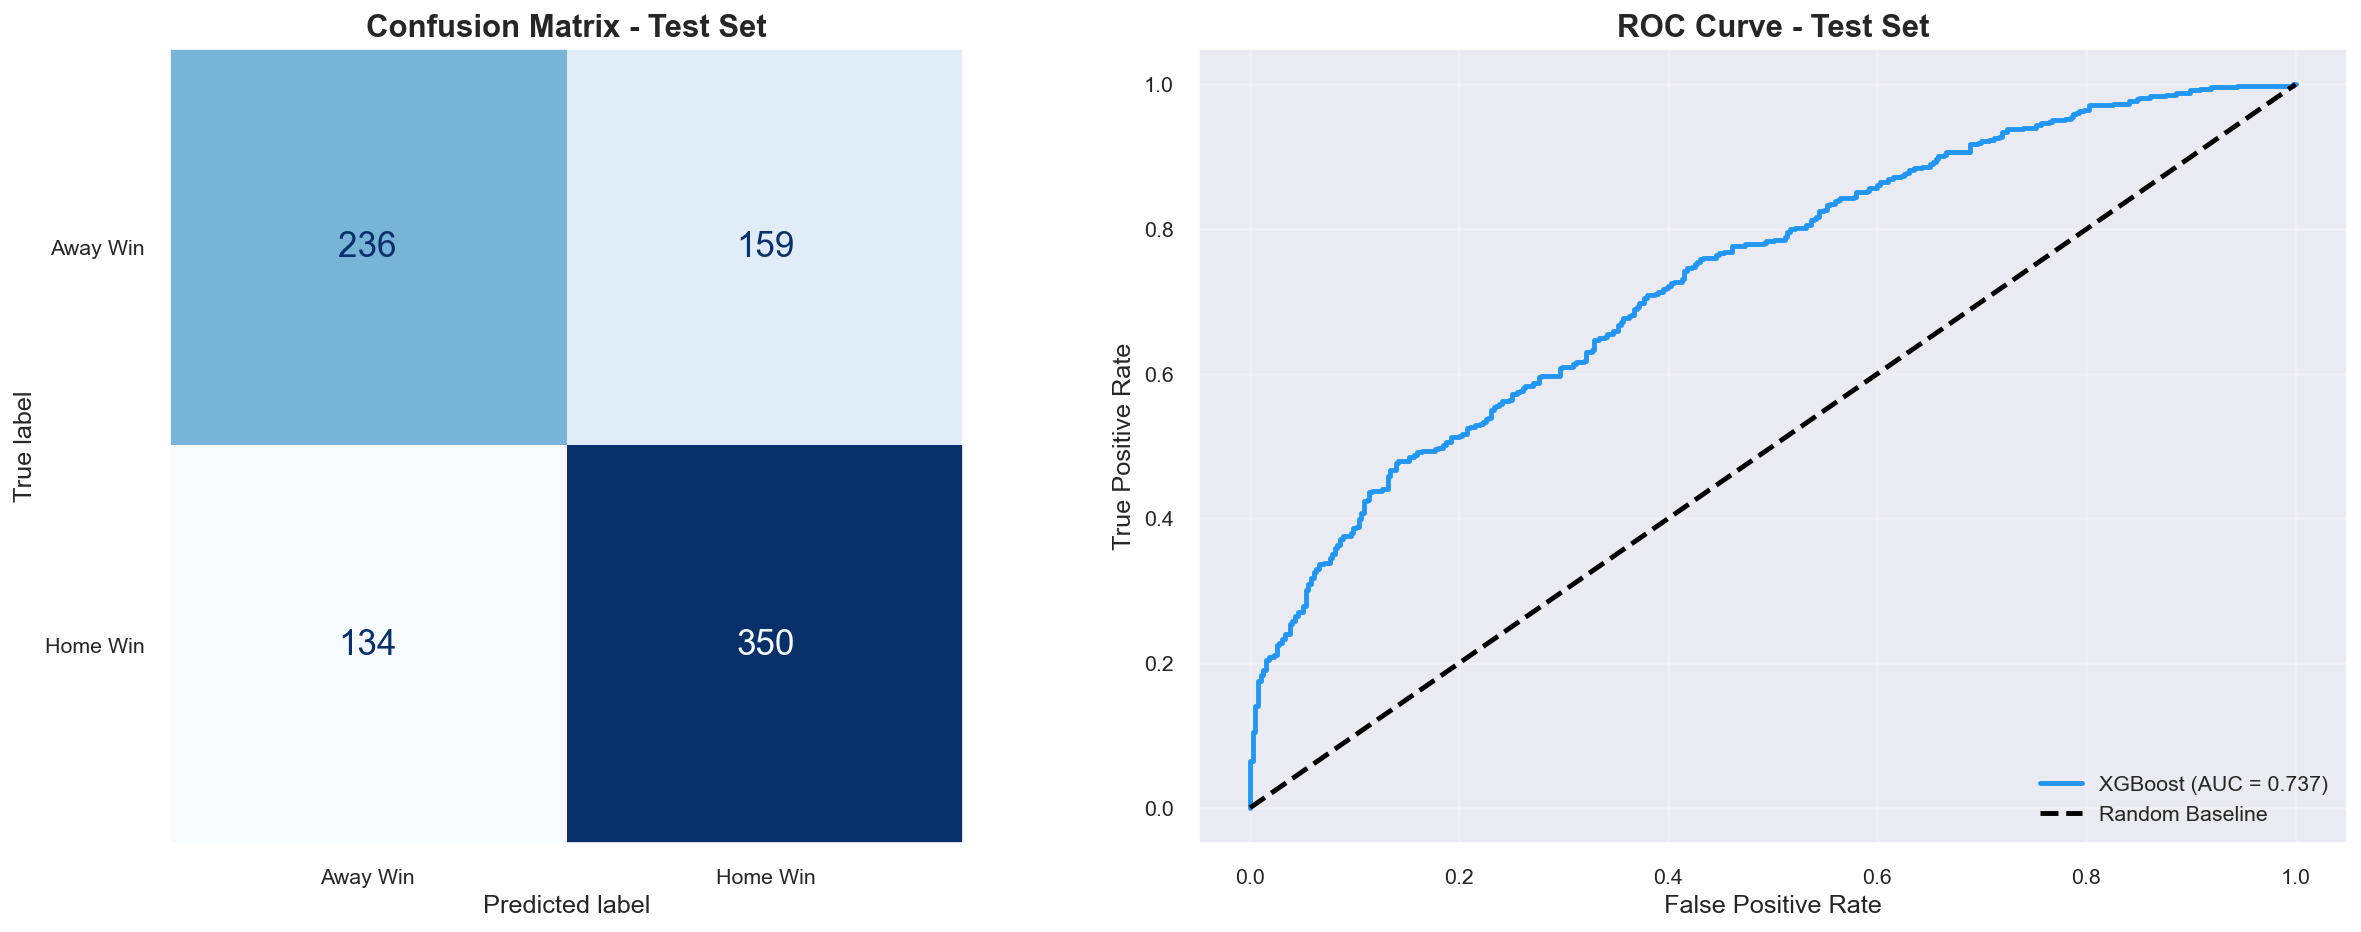

In [41]:
# Confusion matrix + ROC curve
from sklearn.metrics import roc_curve
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
# Confusion matrix
cm = confusion_matrix(y_test, test_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=['Away Win', 'Home Win'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues', values_format='d')
axes[0].set_title('Confusion Matrix - Test Set')
axes[0].grid(False)
# ROC curve
fpr, tpr, _ = roc_curve(y_test, test_probs)
axes[1].plot(fpr, tpr, color='#2196F3',
             label=f'XGBoost (AUC = {auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', label='Random Baseline')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve - Test Set')
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.25)
fig.tight_layout()
plt.show()

## 9. Betting Simulation Ã¢â‚¬â€ ROI, Win Rate, Expected Value

> **Core idea**: Don't bet every game. Only bet when the model's predicted  
> probability meaningfully exceeds the market implied probability (edge > 0).
>
> `Edge = model_prob - market_implied_prob`  
> `EV   = edge Ãƒâ€” stake`  
> `ROI  = total_profit / total_staked`

In [42]:
# Ã¢â€â‚¬Ã¢â€â‚¬ Betting simulation engine Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬

def simulate_betting(
    y_true: pd.Series,
    model_probs: np.ndarray,
    market_odds: np.ndarray = None,
    threshold: float = 0.55,
    edge_min: float = 0.03,
    stake: float = 100.0,
    label: str = '',
) -> pd.DataFrame:
    """
    Simulate flat-stake betting on games where model has edge.

    Parameters
    ----------
    y_true       : actual outcomes
    model_probs  : model's P(home_win)
    market_odds  : market implied P(home_win). If None, uses implied_prob_home from dataset.
    threshold    : minimum model probability to bet home
    edge_min     : minimum edge over market to place bet (anti-vig filter)
    stake        : flat bet size per game
    """
    df = pd.DataFrame({
        'actual'    : y_true.values,
        'model_prob': model_probs,
        'market_p'  : market_odds if market_odds is not None else 0.585,
    })

    # Decide bet direction
    df['bet_home'] = (
        (df['model_prob'] >= threshold) &
        (df['model_prob'] - df['market_p'] >= edge_min)
    ).astype(int)
    df['bet_away'] = (
        (df['model_prob'] <= (1 - threshold)) &
        (df['market_p'] - df['model_prob'] >= edge_min)
    ).astype(int)

    df['bet_placed'] = df['bet_home'] | df['bet_away']

    # Standard -110 odds (bet $110 to win $100) = payout factor 0.909
    PAYOUT = 0.909

    df['profit'] = np.where(
        df['bet_home'] == 1,
        np.where(df['actual'] == 1,  stake * PAYOUT, -stake),
        np.where(
            df['bet_away'] == 1,
            np.where(df['actual'] == 0, stake * PAYOUT, -stake),
            0.0
        )
    )

    bets       = df[df['bet_placed'] == 1]
    total_bet  = len(bets) * stake
    total_prof = bets['profit'].sum()
    win_rate   = (bets['profit'] > 0).mean() if len(bets) > 0 else 0
    roi        = total_prof / total_bet if total_bet > 0 else 0

    print(f'\n--- Betting Simulation {label} ---')
    print(f'  Games available : {len(df):,}')
    print(f'  Bets placed     : {len(bets):,} ({len(bets)/len(df):.1%} of games)')
    print(f'  Win rate        : {win_rate:.1%}')
    print(f'  Total staked    : ${total_bet:,.0f}')
    print(f'  Total profit    : ${total_prof:,.0f}')
    print(f'  ROI             : {roi:.2%}')
    print(f'  EV per bet      : ${total_prof/max(len(bets),1):.2f}')

    return df

# Use ELO-implied prob as market proxy (replace with real odds data when available)
market_probs_test = test_df['implied_prob_home'].values

# Run simulations at different confidence thresholds
for thresh in [0.52, 0.55, 0.58, 0.60, 0.63]:
    simulate_betting(
        y_test, test_probs,
        market_odds=market_probs_test,
        threshold=thresh,
        edge_min=0.02,
        label=f'threshold={thresh}'
    )


--- Betting Simulation threshold=0.52 ---
  Games available : 879
  Bets placed     : 464 (52.8% of games)
  Win rate        : 69.4%
  Total staked    : $46,400
  Total profit    : $15,070
  ROI             : 32.48%
  EV per bet      : $32.48

--- Betting Simulation threshold=0.55 ---
  Games available : 879
  Bets placed     : 439 (49.9% of games)
  Win rate        : 70.4%
  Total staked    : $43,900
  Total profit    : $15,088
  ROI             : 34.37%
  EV per bet      : $34.37

--- Betting Simulation threshold=0.58 ---
  Games available : 879
  Bets placed     : 409 (46.5% of games)
  Win rate        : 70.4%
  Total staked    : $40,900
  Total profit    : $14,079
  ROI             : 34.42%
  EV per bet      : $34.42

--- Betting Simulation threshold=0.6 ---
  Games available : 879
  Bets placed     : 385 (43.8% of games)
  Win rate        : 70.9%
  Total staked    : $38,500
  Total profit    : $13,616
  ROI             : 35.37%
  EV per bet      : $35.37

--- Betting Simulation t

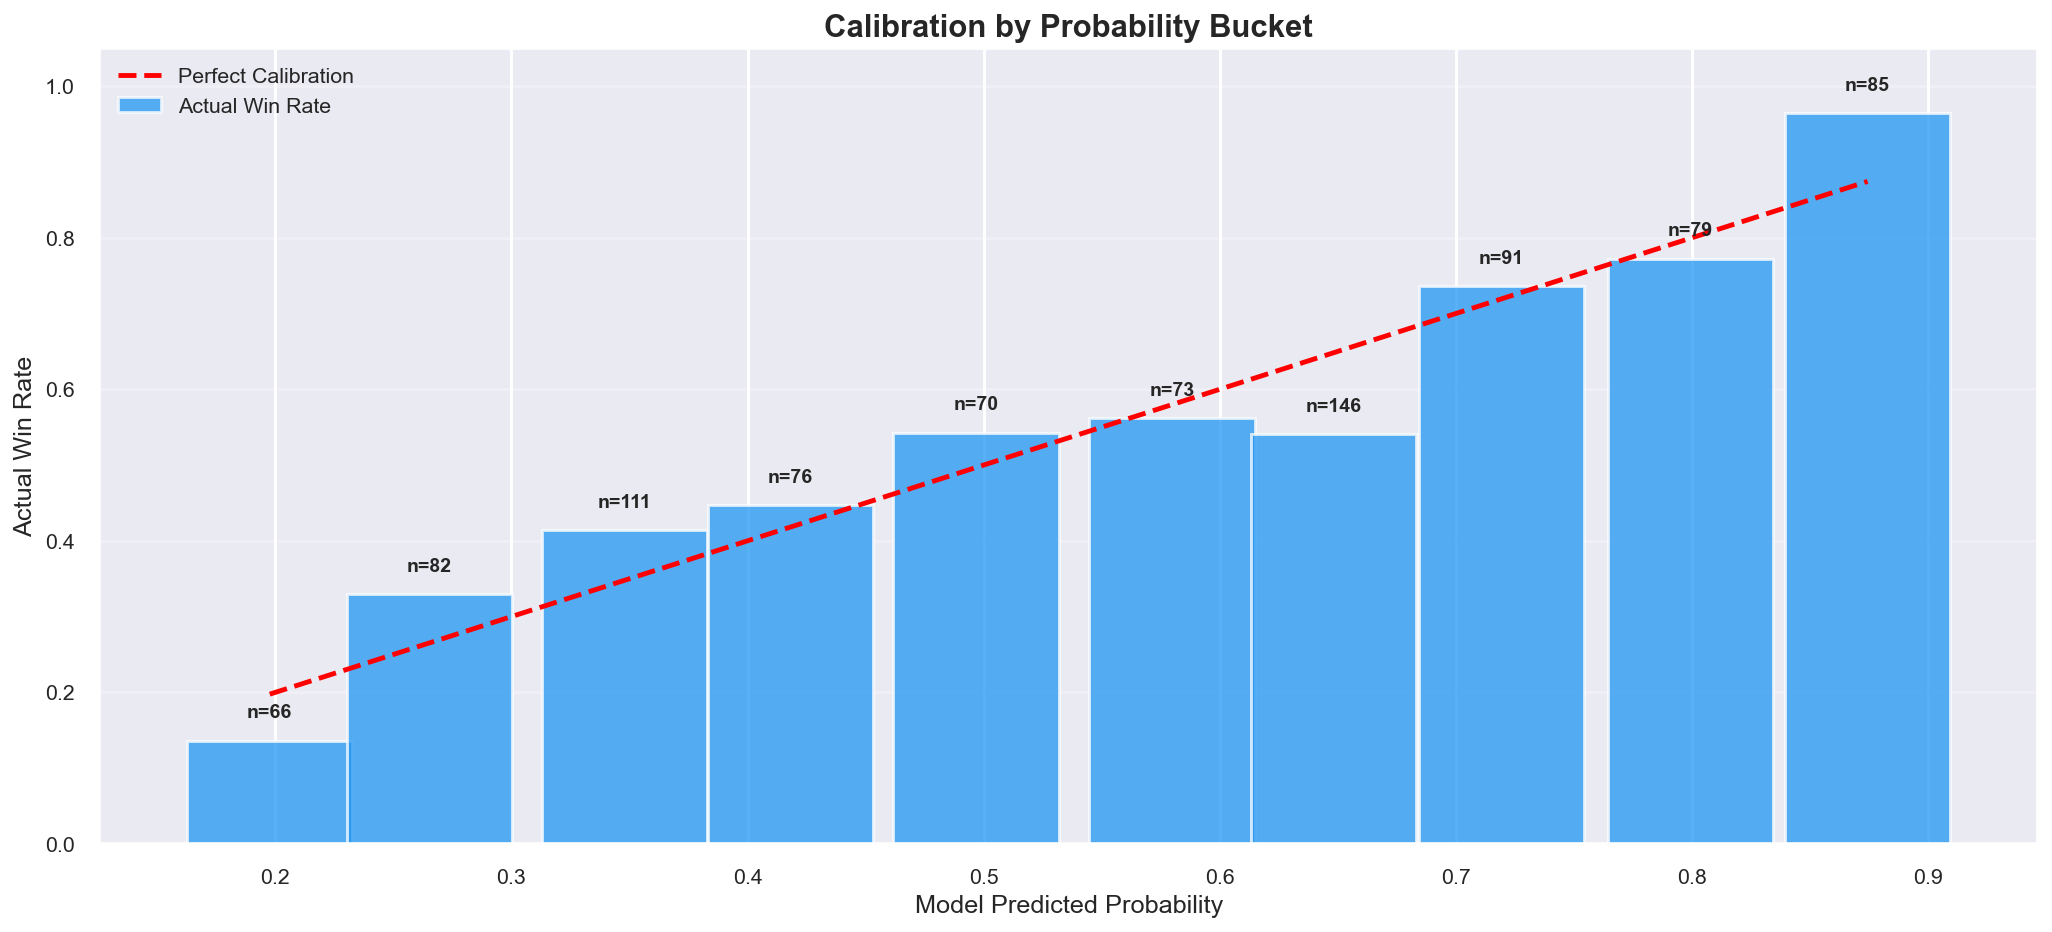

In [43]:
# ROI by probability bucket
# Shows which confidence range actually makes money
test_results = pd.DataFrame({
    'actual'     : y_test.values,
    'model_prob' : test_probs,
    'prob_bucket': pd.cut(test_probs, bins=10, labels=False),
})
bucket_stats = test_results.groupby('prob_bucket').agg(
    games=('actual', 'count'),
    actual_win_rate=('actual', 'mean'),
    avg_model_prob=('model_prob', 'mean'),
).reset_index()
fig, ax = plt.subplots(figsize=(15, 7))
x = bucket_stats['avg_model_prob']
ax.bar(x, bucket_stats['actual_win_rate'], width=0.07, alpha=0.75,
       label='Actual Win Rate', color='#2196F3')
ax.plot(x, x, 'r--', label='Perfect Calibration', linewidth=2.5)
ax.set_xlabel('Model Predicted Probability')
ax.set_ylabel('Actual Win Rate')
ax.set_title('Calibration by Probability Bucket')
ax.set_ylim(0, 1.05)
ax.legend(loc='upper left')
ax.grid(True, axis='y', alpha=0.25)
# Annotate with game counts
for _, row in bucket_stats.iterrows():
    ax.annotate(
        f"n={int(row['games'])}",
        (row['avg_model_prob'], row['actual_win_rate'] + 0.03),
        ha='center',
        fontsize=10,
        fontweight='bold'
    )
fig.tight_layout()
plt.show()

## 10. Probability Calibration

> XGBoost probabilities are often overconfident.  
> Calibration corrects this so `P=0.65` really means the team wins 65% of the time.  
> This is **critical for betting** Ã¢â‚¬â€ miscalibrated probs lead to wrong EV calculations.

Model                    AUC   Acc @thr    Brier
--------------------------------------------------
XGB raw               0.7374     0.6519   0.2101 <-- BEST
XGB calibrated        0.7363     0.6689   0.2041 <-- BEST
LGBM raw              0.7348     0.6667   0.2056
LGBM calibrated       0.7306     0.6667   0.2063
Stacker raw           0.7366     0.6667   0.2066
Stacker cal           0.7348     0.6712   0.2057 <-- BEST
Best model: Stacker cal  ->  0.6712 (67.1%)


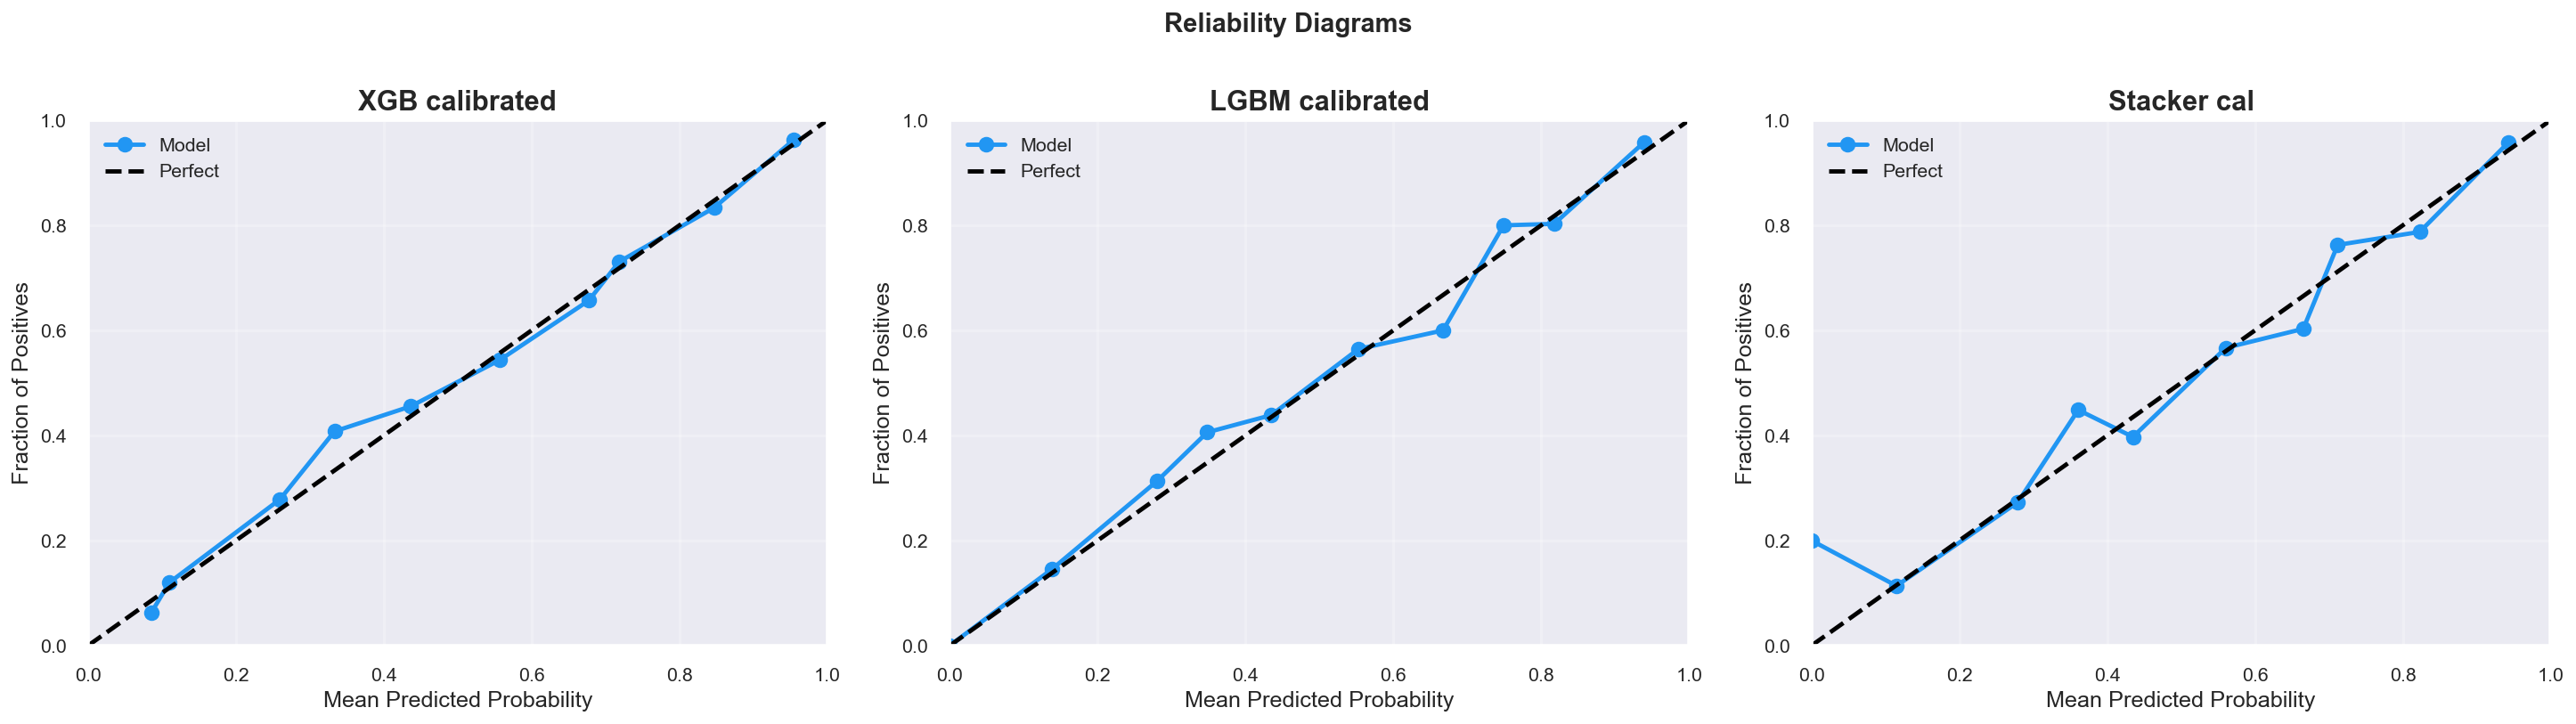

In [44]:
# ── Calibrate XGBoost, LightGBM, and Stacker ─────────────────────────────────
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.isotonic import IsotonicRegression

# Calibrate XGBoost
try:
    from sklearn.frozen import FrozenEstimator
    xgb_cal = CalibratedClassifierCV(FrozenEstimator(final_model), method='isotonic', cv=None)
except ImportError:
    xgb_cal = CalibratedClassifierCV(final_model, method='isotonic', cv='prefit')
xgb_cal.fit(X_valid, y_valid)

# Calibrate LightGBM
try:
    lgbm_cal = CalibratedClassifierCV(FrozenEstimator(lgbm_model), method='isotonic', cv=None)
except Exception:
    lgbm_cal = CalibratedClassifierCV(lgbm_model, method='isotonic', cv='prefit')
lgbm_cal.fit(X_valid, y_valid)

# Calibrate Stacker via isotonic regression on its own validation probs
iso_stacker = IsotonicRegression(out_of_bounds='clip')
iso_stacker.fit(stack_val_probs, y_valid)

# Test-set calibrated probabilities
xgb_cal_test   = xgb_cal.predict_proba(X_test)[:, 1]
lgbm_cal_test  = lgbm_cal.predict_proba(X_test)[:, 1]
stack_cal_test = iso_stacker.predict(stack_test_probs)

# ── Full comparison table ─────────────────────────────────────────────────────
candidates = {
    'XGB raw'        : xgb_test_probs,
    'XGB calibrated' : xgb_cal_test,
    'LGBM raw'       : lgbm_test_probs,
    'LGBM calibrated': lgbm_cal_test,
    'Stacker raw'    : stack_test_probs,
    'Stacker cal'    : stack_cal_test,
}
print(f"{'Model':<20} {'AUC':>7} {'Acc @thr':>10} {'Brier':>8}")
print('-' * 50)
best_acc, best_name, best_probs = 0, '', None
for name, probs in candidates.items():
    auc_s = roc_auc_score(y_test, probs)
    acc_s = accuracy_score(y_test, (probs >= FINAL_THRESHOLD).astype(int))
    bri_s = brier_score_loss(y_test, probs)
    marker = ' <-- BEST' if acc_s > best_acc else ''
    if acc_s > best_acc:
        best_acc, best_name, best_probs = acc_s, name, probs
    print(f'{name:<20} {auc_s:>7.4f} {acc_s:>10.4f} {bri_s:>8.4f}{marker}')

print(f'Best model: {best_name}  ->  {best_acc:.4f} ({best_acc:.1%})')

# Set cal_probs to best for summary cell
cal_probs = best_probs
calibrated_model = xgb_cal

# ── Reliability diagram for top 3 ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(21, 6))
for (title, probs), ax in zip(
    [('XGB calibrated', xgb_cal_test),
     ('LGBM calibrated', lgbm_cal_test),
     ('Stacker cal', stack_cal_test)],
    axes
):
    frac_pos, mean_pred = calibration_curve(y_test, probs, n_bins=10)
    ax.plot(mean_pred, frac_pos, 'o-', color='#2196F3', linewidth=2.5, label='Model')
    ax.plot([0, 1], [0, 1], 'k--', label='Perfect')
    ax.set_title(title)
    ax.set_xlabel('Mean Predicted Probability')
    ax.set_ylabel('Fraction of Positives')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.25); ax.legend()
plt.suptitle('Reliability Diagrams', fontsize=15, fontweight='bold')
fig.tight_layout()
plt.show()


## 11. Feature Importance

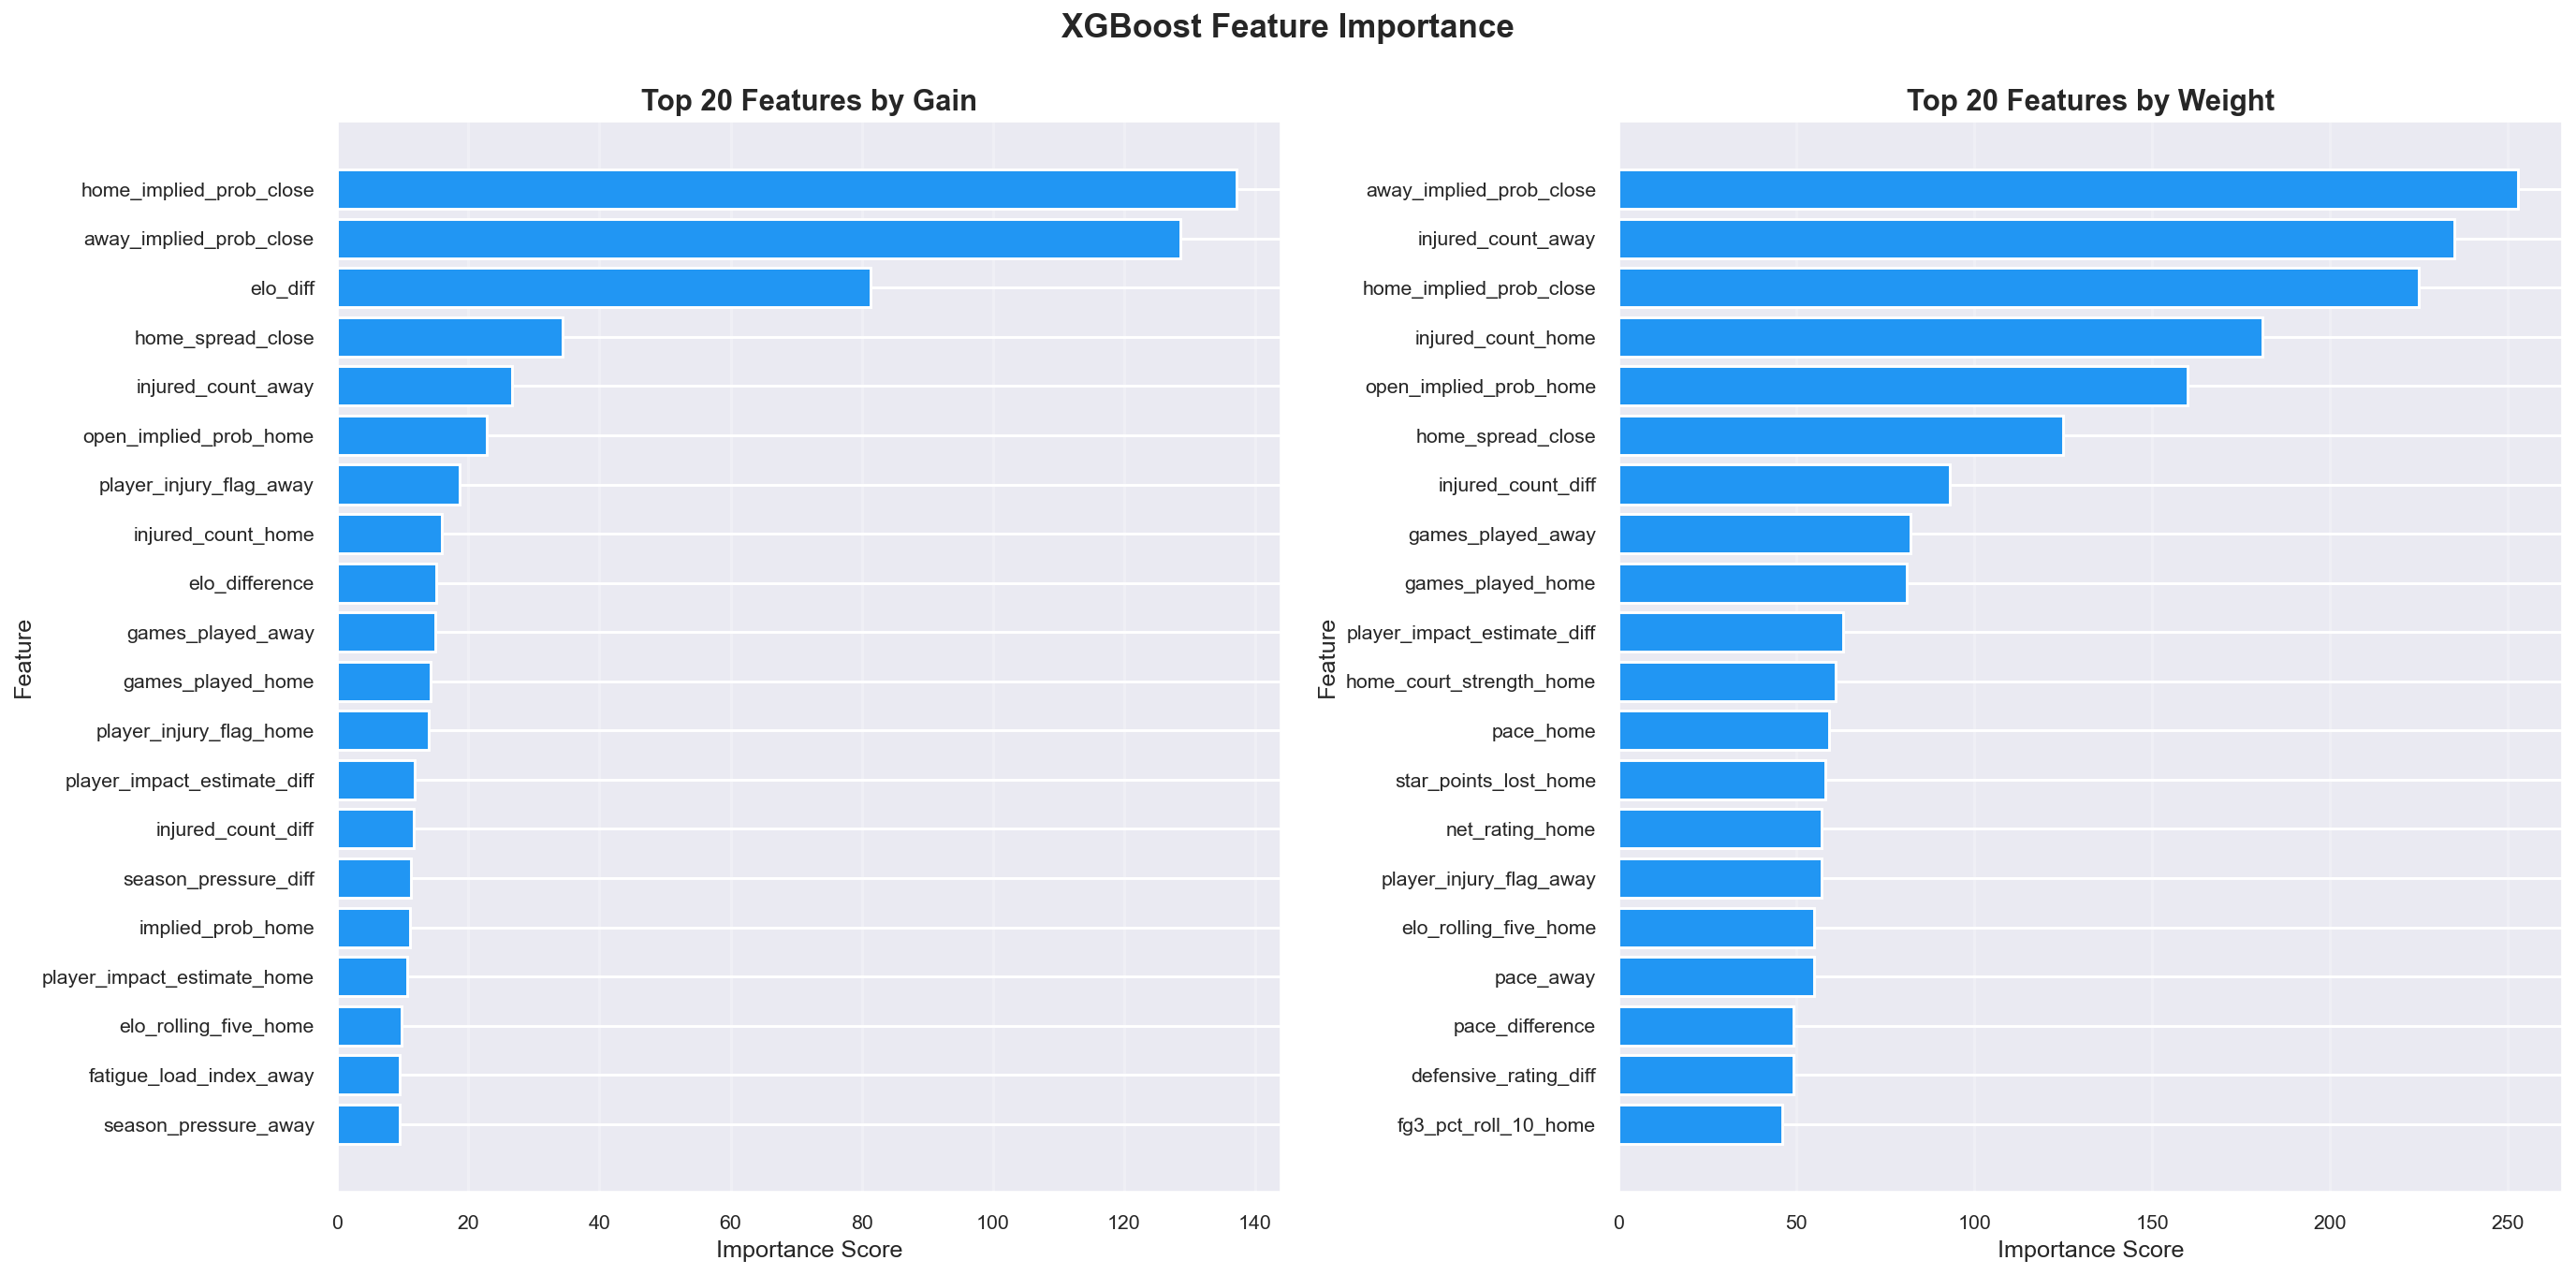

Top 15 features by GAIN (most predictive):
home_implied_prob_close       137.1720
away_implied_prob_close       128.5410
elo_diff                       81.4016
home_spread_close              34.4288
injured_count_away             26.6653
open_implied_prob_home         22.8773
player_injury_flag_away        18.6704
injured_count_home             15.9854
elo_difference                 15.1656
games_played_away              14.9904
games_played_home              14.2450
player_injury_flag_home        13.9973
player_impact_estimate_diff    11.8555
injured_count_diff             11.7041
season_pressure_diff           11.2054

Showing the top 20 features in the chart so names remain readable.


In [45]:
# Three types of XGBoost feature importance
# weight   : how many times a feature is used to split
# gain     : average improvement in loss when feature is used (MOST RELIABLE)
# cover    : average coverage of samples affected by splits on this feature
importance_gain = pd.Series(
    final_model.get_booster().get_score(importance_type='gain'),
    name='gain'
).sort_values(ascending=False)
importance_weight = pd.Series(
    final_model.get_booster().get_score(importance_type='weight'),
    name='weight'
).sort_values(ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(20, 10))
top_n = 20
for ax, imp, title in [
    (axes[0], importance_gain.head(top_n).sort_values(),   f'Top {top_n} Features by Gain'),
    (axes[1], importance_weight.head(top_n).sort_values(), f'Top {top_n} Features by Weight'),
]:
    ax.barh(imp.index, imp.values, color='#2196F3')
    ax.set_title(title)
    ax.set_xlabel('Importance Score')
    ax.set_ylabel('Feature')
    ax.grid(True, axis='x', alpha=0.25)
plt.suptitle('XGBoost Feature Importance', fontsize=18, fontweight='bold')
fig.tight_layout()
plt.show()
print('Top 15 features by GAIN (most predictive):')
print(importance_gain.head(15).to_string())
print('\nShowing the top 20 features in the chart so names remain readable.')

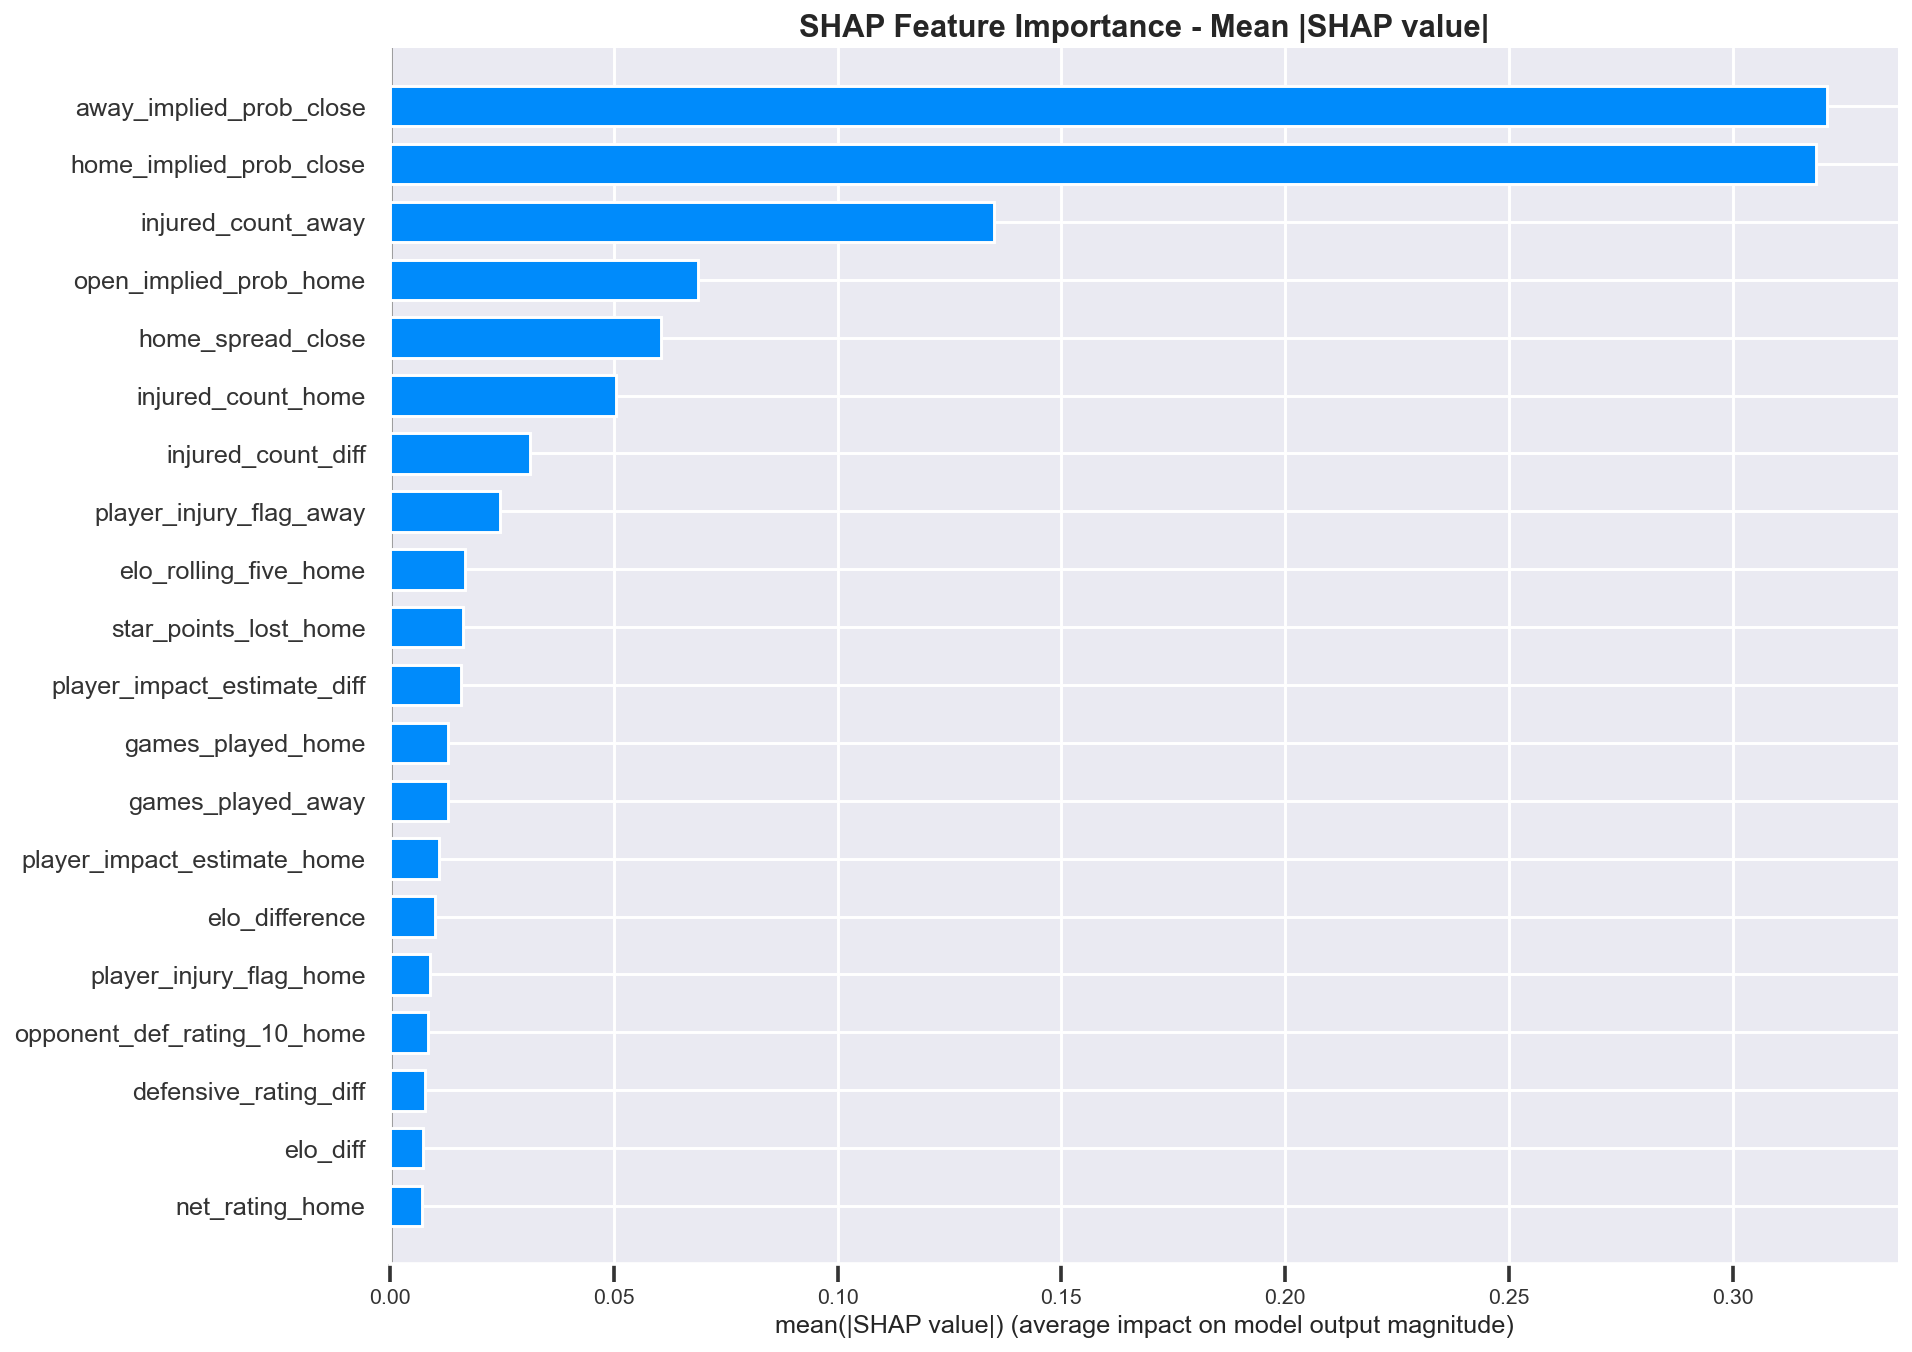

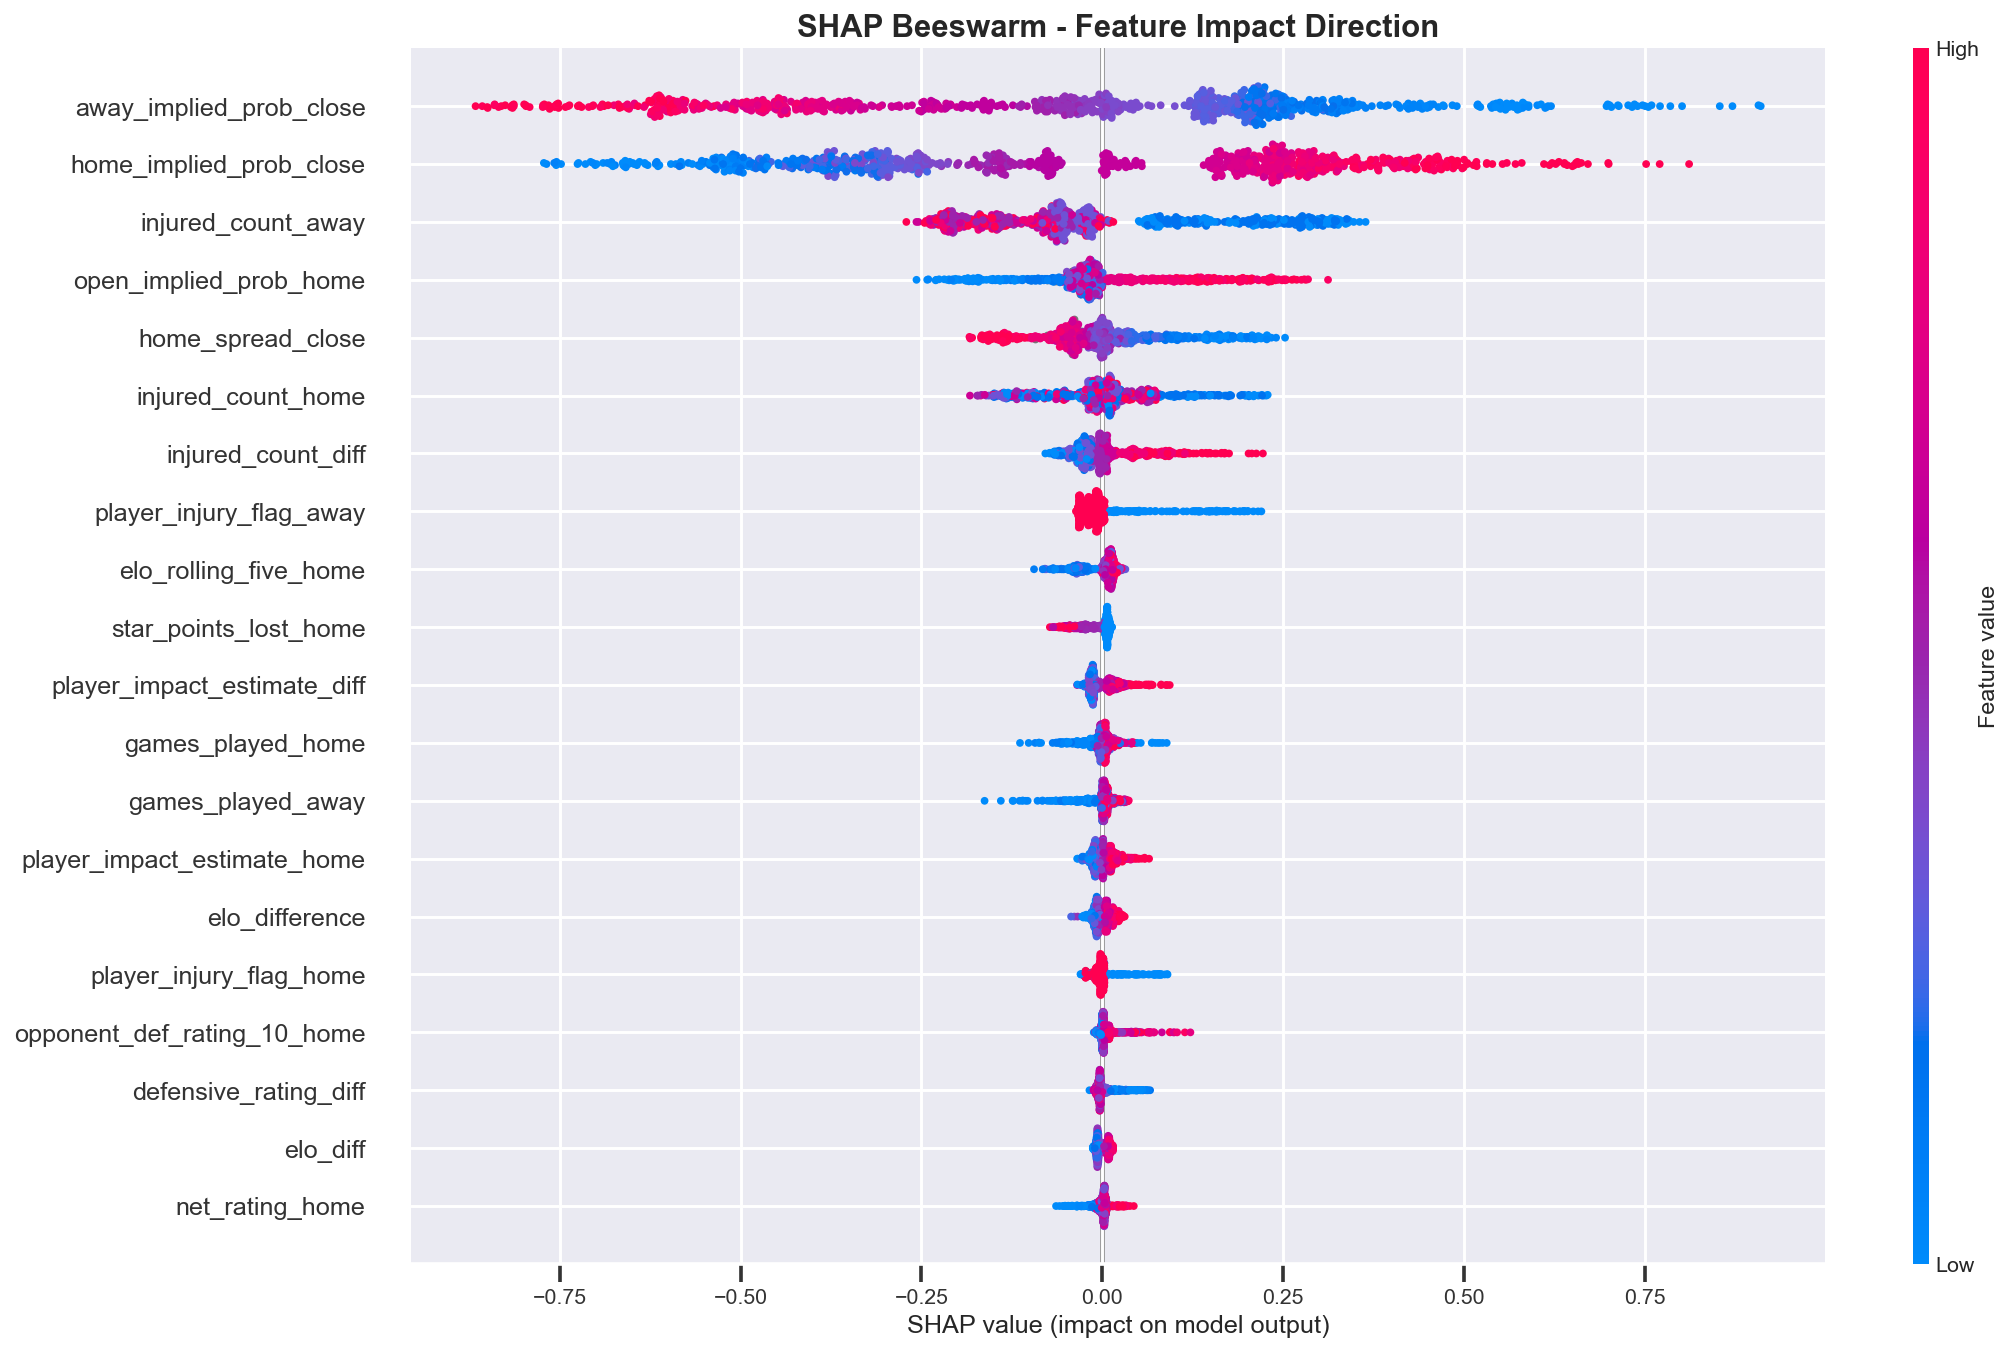

In [46]:
# SHAP values (detailed feature impact per prediction)
# SHAP explains WHY the model made each prediction - essential for trust & debugging
try:
    import shap
    explainer = shap.TreeExplainer(final_model)
    shap_vals = explainer.shap_values(X_test)
    plt.figure(figsize=(14, 10))
    shap.summary_plot(
        shap_vals,
        X_test,
        plot_type='bar',
        show=False,
        max_display=20,
        plot_size=(14, 10)
    )
    plt.title('SHAP Feature Importance - Mean |SHAP value|', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    plt.figure(figsize=(16, 10))
    shap.summary_plot(
        shap_vals,
        X_test,
        show=False,
        max_display=20,
        plot_size=(16, 10)
    )
    plt.title('SHAP Beeswarm - Feature Impact Direction', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
except ImportError:
    print('SHAP not installed. Run: pip install shap')
    print('Skipping SHAP analysis.')

## 12. Save Models for Production

In [47]:
import json as _json
from datetime import datetime
timestamp = datetime.now().strftime('%Y%m%d_%H%M')

# 1. XGBoost
xgb_path = f'{MODELS_DIR}/xgb_nba_{timestamp}.json'
final_model.save_model(xgb_path)
print(f'Saved XGBoost          : {xgb_path}')

# 2. LightGBM
lgbm_path = f'{MODELS_DIR}/lgbm_nba_{timestamp}.joblib'
joblib.dump(lgbm_model, lgbm_path)
print(f'Saved LightGBM         : {lgbm_path}')

# 3. Stacker
stacker_path = f'{MODELS_DIR}/stacker_{timestamp}.joblib'
joblib.dump(stacker, stacker_path)
print(f'Saved stacker          : {stacker_path}')

# 4. Calibrated XGBoost
cal_path = f'{MODELS_DIR}/xgb_calibrated_{timestamp}.joblib'
joblib.dump(calibrated_model, cal_path)
print(f'Saved XGB calibrated   : {cal_path}')

# 5. Isotonic calibrator for stacker
iso_path = f'{MODELS_DIR}/iso_stacker_{timestamp}.joblib'
joblib.dump(iso_stacker, iso_path)
print(f'Saved stacker isotonic : {iso_path}')

# 6. Feature list
feat_path = f'{MODELS_DIR}/feature_list_{timestamp}.json'
with open(feat_path, 'w') as f:
    _json.dump(ALL_FEATURES, f, indent=2)
print(f'Saved feature list     : {feat_path}')

# 7. Metadata
meta = {
    'timestamp'      : timestamp,
    'train_seasons'  : f'2003-{TRAIN_END}',
    'valid_seasons'  : f'{VALID_START}-{VALID_END}',
    'test_season'    : str(TEST_START),
    'n_features'     : len(ALL_FEATURES),
    'n_train_rows'   : len(X_train),
    'test_auc_xgb'   : round(roc_auc_score(y_test, xgb_test_probs), 4),
    'test_auc_lgbm'  : round(roc_auc_score(y_test, lgbm_test_probs), 4),
    'test_auc_stack' : round(roc_auc_score(y_test, stack_test_probs), 4),
    'best_model'     : best_name,
    'best_accuracy'  : round(best_acc, 4),
    'xgb_best_iter'  : final_model.best_iteration,
    'lgbm_best_iter' : lgbm_model.best_iteration_,
    'stacker_coefs'  : {'xgb': round(float(xgb_w), 4), 'lgbm': round(float(lgbm_w), 4)},
    'best_params_xgb': best_params,
}
meta_path = f'{MODELS_DIR}/model_meta_{timestamp}.json'
with open(meta_path, 'w') as f:
    _json.dump(meta, f, indent=2)
print(f'Saved metadata         : {meta_path}')
print(f'All artifacts saved to : {MODELS_DIR}/')


Saved XGBoost          : ../models/xgb_nba_20260421_2115.json
Saved LightGBM         : ../models/lgbm_nba_20260421_2115.joblib
Saved stacker          : ../models/stacker_20260421_2115.joblib
Saved XGB calibrated   : ../models/xgb_calibrated_20260421_2115.joblib
Saved stacker isotonic : ../models/iso_stacker_20260421_2115.joblib
Saved feature list     : ../models/feature_list_20260421_2115.json
Saved metadata         : ../models/model_meta_20260421_2115.json
All artifacts saved to : ../models/


## Summary Card

In [49]:
# Final summary
if "cal_probs" in globals():
    summary_probs = cal_probs
    summary_label = f"Best calibrated: {best_name}"
else:
    summary_probs = stack_test_probs
    summary_label = "Stacker (calibration step not run)"
summary_acc   = accuracy_score(y_test, (summary_probs >= FINAL_THRESHOLD).astype(int))
summary_auc   = roc_auc_score(y_test, summary_probs)
summary_brier = brier_score_loss(y_test, summary_probs)

print("=" * 57)
print("  NBA BETTING MODEL - FINAL RESULTS SUMMARY")
print("=" * 57)
print(f"  Dataset          : {len(master):,} games (2003-2025)")
print(f"  Features used    : {len(ALL_FEATURES)}")
print(f"  Test season      : 2024 ({len(y_test)} games)")
print()
print("  --- Individual Models (test set) ---")
print(f"  XGBoost raw      : {roc_auc_score(y_test, xgb_test_probs):.4f} AUC  {accuracy_score(y_test,(xgb_test_probs>=FINAL_THRESHOLD).astype(int)):.4f} acc")
print(f"  LightGBM raw     : {roc_auc_score(y_test, lgbm_test_probs):.4f} AUC  {accuracy_score(y_test,(lgbm_test_probs>=FINAL_THRESHOLD).astype(int)):.4f} acc")
print(f"  Stacker raw      : {roc_auc_score(y_test, stack_test_probs):.4f} AUC  {accuracy_score(y_test,(stack_test_probs>=FINAL_THRESHOLD).astype(int)):.4f} acc")
print()
print("  --- Best Model (post-calibration) ---")
print(f"  Model            : {summary_label}")
print(f"  Accuracy         : {summary_acc:.4f}  ({summary_acc:.1%})")
print(f"  ROC-AUC          : {summary_auc:.4f}")
print(f"  Brier Score      : {summary_brier:.4f}")
print(f"  Baseline         : {y_test.mean():.4f} (always pick home)")
print(f"  Improvement      : +{summary_acc - y_test.mean():.4f} over baseline")
print()
print("  --- Ensemble Info ---")
print(f"  XGB best iter    : {final_model.best_iteration}")
print(f"  LGBM best iter   : {lgbm_model.best_iteration_}")
print(f"  Stacker coefs    : XGB={xgb_w:.3f}  LGBM={lgbm_w:.3f}  bias={stacker.intercept_[0]:.3f}")
print(f"  Threshold        : {FINAL_THRESHOLD}  (macro-F1 tuned on val)")
print()
print("  --- Next Steps to 70% ---")
print("  1. Get closing odds 2018-2025 (top features are market probs)")
print("  2. Real-time injury reports before game time")
print("  3. Daily retraining pipeline")
print("=" * 57)


  NBA BETTING MODEL - FINAL RESULTS SUMMARY
  Dataset          : 29,575 games (2003-2025)
  Features used    : 112
  Test season      : 2024 (879 games)

  --- Individual Models (test set) ---
  XGBoost raw      : 0.7374 AUC  0.6519 acc
  LightGBM raw     : 0.7348 AUC  0.6667 acc
  Stacker raw      : 0.7366 AUC  0.6667 acc

  --- Best Model (post-calibration) ---
  Model            : Best calibrated: Stacker cal
  Accuracy         : 0.6712  (67.1%)
  ROC-AUC          : 0.7348
  Brier Score      : 0.2057
  Baseline         : 0.5506 (always pick home)
  Improvement      : +0.1206 over baseline

  --- Ensemble Info ---
  XGB best iter    : 211
  LGBM best iter   : 168
  Stacker coefs    : XGB=3.034  LGBM=1.772  bias=-2.208
  Threshold        : 0.5  (macro-F1 tuned on val)

  --- Next Steps to 70% ---
  1. Get closing odds 2018-2025 (top features are market probs)
  2. Real-time injury reports before game time
  3. Daily retraining pipeline
